# 43. 제안서 수치 전체 재계산 (41개 규칙 기준 확정)

## 목적
84% 성공률, 규칙별 QED/LogP 차트, 다중문제분자 비율, 종합 스코어를
모두 최신 라이브러리(41개 규칙)로 재계산해 일관성 확보.

## 재계산 대상
- Held-out 커버리지 (참고용 재확인)
- 단일 문제 분자 최소 1단계 개선 성공률 (기존 84%)
- 다중 문제 분자 비율 (기존 16.9%)
- 100개 검증 표본 재생성 → 규칙별 ΔQED/ΔLogP → 차트
- 다목적 종합 스코어(같은 100개 표본)

In [ ]:
!pip install rdkit -q
!pip install fuzzywuzzy python-Levenshtein -q
!pip install PyTDC --no-deps -q
!pip install PyYAML tqdm requests -q
!pip install openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/Dec32th/laidd-2026.git
%cd /content/laidd-2026

Cloning into 'laidd-2026'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 578 (delta 14), reused 27 (delta 9), pack-reused 540 (from 1)
Receiving objects: 100% (578/578), 5.13 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (331/331), done.
/content/laidd-2026


In [ ]:
!git config --global user.email "hyekyeong.w@gmail.com"
!git config --global user.name "Dec32th"

In [ ]:
import importlib, random, json
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, Descriptors3D, DataStructs, QED, AllChem, FilterCatalog

import src.tools.replacement_library
import src.tools.molecule_editor
import src.tools.atom_editor
import src.tools.toxicophore_detector
import src.tools.agent
import src.tools.precedent_library
import src.tools.scoring

from src.tools.data_prep import load_tox21_clean
from src.tools.toxicophore_detector import detect_toxicophores
from src.tools.replacement_library import get_replacement_candidates
from src.tools.molecule_editor import propose_fix, canonicalize, iterative_fix_loop
from src.tools.agent import ask_llm_which_problem_to_fix, ask_llm_which_candidate_to_use, _call_llm, _parse_json_response
from src.tools.precedent_library import PRECEDENT_LIBRARY, get_precedents
from src.tools.scoring import compute_multi_objective_score

data = load_tox21_clean(random_state=7)
n_rules = len(get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY'])
print(f"라이브러리 규칙 수: {n_rules}")

[10:50:49] WARNING: not removing hydrogen atom without neighbors
[10:50:49] Explicit valence for atom # 8 Al, 6, is greater than permitted
[10:50:50] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:50:50] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:50:50] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:50:51] Explicit valence for atom # 9 Al, 6, is greater than permitted
[10:50:51] Explicit valence for atom # 5 Al, 6, is greater than permitted
[10:50:51] Explicit valence for atom # 16 Al, 6, is greater than permitted
[10:50:51] Explicit valence for atom # 20 Al, 6, is greater than permitted


전체: 7831개, 파싱 성공: 7823개, 파싱 실패(제외): 8개


[10:50:52] WARNING: not removing hydrogen atom without neighbors


라이브러리 규칙 수: 42


In [ ]:
# 셀 5 — Qwen 연결
from openai import OpenAI
dashscope_key = userdata.get('DASHSCOPE_API_KEY')
client_qwen = OpenAI(api_key=dashscope_key, base_url="https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1")
print("준비 완료")

준비 완료


In [ ]:
# SA Score 준비
import urllib.request, sys
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py", "sascorer.py")
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz", "fpscores.pkl.gz")
sys.path.append('.')
import sascorer

_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
print("준비 완료")

준비 완료


In [ ]:
count_final = 0
for s in data['smiles_valid']:
    p = detect_toxicophores(s)
    if any(get_replacement_candidates(x['rule_name']) is not None for x in p):
        count_final += 1

coverage_pct = count_final / len(data['smiles_valid']) * 100
print(f"[수치 1] 커버리지: {count_final}/{len(data['smiles_valid'])} ({coverage_pct:.1f}%), 규칙 {n_rules}개")

[수치 1] 커버리지: 589/1173 (50.2%), 규칙 42개


In [ ]:
single_problem_molecules = []
multi_problem_molecules = []

for s in data['smiles_valid']:
    p = detect_toxicophores(s)
    known = [x for x in p if get_replacement_candidates(x['rule_name']) is not None]
    if len(known) == 1:
        single_problem_molecules.append(s)
    elif len(known) >= 2:
        multi_problem_molecules.append(s)

print(f"단일 문제 분자: {len(single_problem_molecules)}개")
print(f"다중 문제 분자: {len(multi_problem_molecules)}개")

random.seed(7)
sample_single = random.sample(single_problem_molecules, min(100, len(single_problem_molecules)))

success_count = 0
partial_count = 0
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    if result['status'] == 'success':
        success_count += 1
        partial_count += 1
    elif len(result['history']) - 1 >= 1:  # 최소 1단계 이상 진행
        partial_count += 1

success_rate = success_count / len(sample_single) * 100
partial_rate = partial_count / len(sample_single) * 100
print(f"\n[수치 2] 완전 해결(success): {success_count}/{len(sample_single)} ({success_rate:.0f}%)")
print(f"[수치 3] 최소 1단계 이상 개선: {partial_count}/{len(sample_single)} ({partial_rate:.0f}%)")

단일 문제 분자: 415개
다중 문제 분자: 174개

[수치 2] 완전 해결(success): 50/100 (50%)
[수치 3] 최소 1단계 이상 개선: 73/100 (73%)


In [ ]:
total_known_problem_molecules = len(single_problem_molecules) + len(multi_problem_molecules)
multi_ratio = len(multi_problem_molecules) / total_known_problem_molecules * 100

multi_problem_counts = []
for s in multi_problem_molecules:
    p = detect_toxicophores(s)
    known_count = sum(1 for x in p if get_replacement_candidates(x['rule_name']) is not None)
    multi_problem_counts.append(known_count)

print(f"[수치 4] 다중 문제 분자 비율: {len(multi_problem_molecules)}/{total_known_problem_molecules} ({multi_ratio:.1f}%)")
print(f"[수치 5] 다중 문제 분자 평균 문제 수: {np.mean(multi_problem_counts):.2f}개, 최대: {max(multi_problem_counts)}개")

[수치 4] 다중 문제 분자 비율: 174/589 (29.5%)
[수치 5] 다중 문제 분자 평균 문제 수: 2.14개, 최대: 3개


In [ ]:
verification_v43 = []
for s in data['smiles_valid']:
    problems = detect_toxicophores(s)
    known = [p for p in problems if get_replacement_candidates(p['rule_name']) is not None]
    if not known:
        continue
    rule = known[0]['rule_name']
    fixed = propose_fix(s, rule, candidate_idx=0)
    if fixed is None or not fixed['is_valid']:
        continue
    verification_v43.append({"original": s, "fixed": fixed['new_smiles'], "rule": rule})
    if len(verification_v43) >= 100:
        break

print(f"[수치 6] 검증 표본 확보: {len(verification_v43)}개 (41개 규칙 기준)")

[수치 6] 검증 표본 확보: 100개 (41개 규칙 기준)


In [ ]:
rule_metrics_v43 = {}
for c in verification_v43:
    mol_o = Chem.MolFromSmiles(c['original'])
    mol_f = Chem.MolFromSmiles(c['fixed'])
    if mol_o is None or mol_f is None:
        continue
    delta_qed = QED.qed(mol_f) - QED.qed(mol_o)
    delta_logp = Descriptors.MolLogP(mol_f) - Descriptors.MolLogP(mol_o)
    rule_metrics_v43.setdefault(c['rule'], []).append({"dqed": delta_qed, "dlogp": delta_logp})

print("[수치 7] 규칙별 평균 ΔQED, ΔLogP (표본수 ≥2, 41개 규칙 기준):")
rule_qed_logp_summary = {}
for rule, vals in sorted(rule_metrics_v43.items(), key=lambda x: -len(x[1])):
    if len(vals) < 2:
        continue
    avg_qed = sum(v['dqed'] for v in vals) / len(vals)
    avg_logp = sum(v['dlogp'] for v in vals) / len(vals)
    rule_qed_logp_summary[rule] = {"n": len(vals), "avg_dqed": avg_qed, "avg_dlogp": avg_logp}
    print(f"  {rule}: n={len(vals)}, ΔQED={avg_qed:+.3f}, ΔLogP={avg_logp:+.3f}")

[수치 7] 규칙별 평균 ΔQED, ΔLogP (표본수 ≥2, 41개 규칙 기준):
  Aliphatic_long_chain: n=25, ΔQED=+0.002, ΔLogP=-0.764
  nitro_group: n=10, ΔQED=+0.027, ΔLogP=-0.326
  isolated_alkene: n=9, ΔQED=+0.073, ΔLogP=+0.128
  aniline: n=8, ΔQED=+0.073, ΔLogP=+0.376
  alkyl_halide: n=8, ΔQED=+0.001, ΔLogP=-1.144
  aldehyde: n=6, ΔQED=+0.109, ΔLogP=-0.714
  Michael_acceptor_1: n=4, ΔQED=+0.061, ΔLogP=-0.201
  imine_1_general: n=4, ΔQED=+0.053, ΔLogP=-0.624
  isocyanate: n=3, ΔQED=+0.031, ΔLogP=-0.382
  quaternary_nitrogen_2: n=3, ΔQED=-0.043, ΔLogP=-2.236
  azo_A(324): n=3, ΔQED=-0.108, ΔLogP=-1.104
  triple_bond: n=2, ΔQED=+0.059, ΔLogP=+0.777
  phosphor: n=2, ΔQED=+0.053, ΔLogP=-0.581
  stilbene: n=2, ΔQED=+0.036, ΔLogP=-0.385


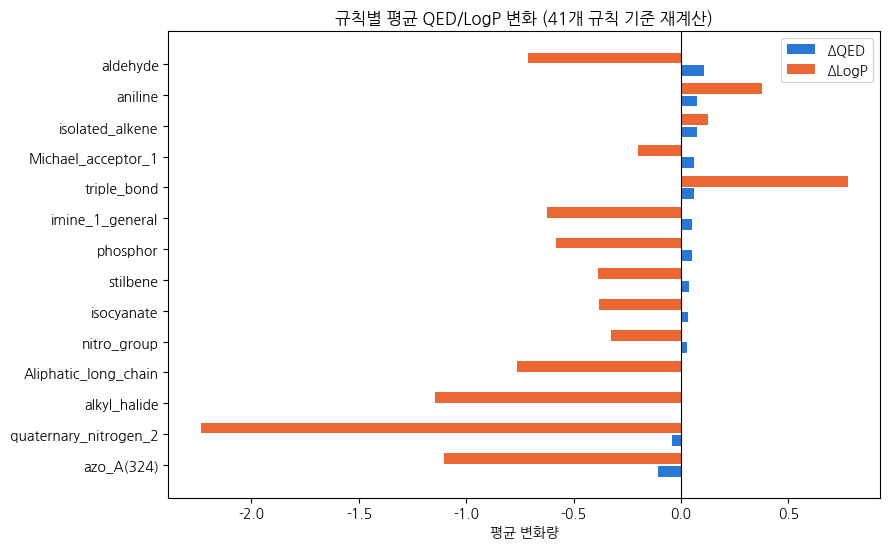

저장: outputs/rule_qed_logp_chart_final.png


In [ ]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import os
os.makedirs("outputs", exist_ok=True)

sorted_rules = sorted(rule_qed_logp_summary.items(), key=lambda x: x[1]['avg_dqed'])
labels = [r[0] for r in sorted_rules]
qed_vals = [r[1]['avg_dqed'] for r in sorted_rules]
logp_vals = [r[1]['avg_dlogp'] for r in sorted_rules]

y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, max(5, len(labels)*0.4)))
ax.barh(y - 0.2, qed_vals, height=0.35, label='ΔQED', color='#2a78d6')
ax.barh(y + 0.2, logp_vals, height=0.35, label='ΔLogP', color='#eb6834')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('평균 변화량')
ax.set_title('규칙별 평균 QED/LogP 변화 (41개 규칙 기준 재계산)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/rule_qed_logp_chart_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("저장: outputs/rule_qed_logp_chart_final.png")

In [ ]:
docking_deltas = {
    'hydroquinone': -0.79, 'quinone_A(370)': -0.79,
    'catechol': 0.31, 'Michael_acceptor_1': 0.05,
}

composite_scores = []
for c in verification_v43:
    precedent_delta = docking_deltas.get(c['rule'])
    score_result = compute_multi_objective_score(
        c['original'], c['fixed'], c['rule'],
        sascorer_module=sascorer, precedent_docking_delta=precedent_delta
    )
    if score_result and score_result['composite_score'] is not None:
        composite_scores.append({"score": score_result['composite_score'], "has_docking": precedent_delta is not None})

all_scores = [s['score'] for s in composite_scores]
with_docking = [s['score'] for s in composite_scores if s['has_docking']]
without_docking = [s['score'] for s in composite_scores if not s['has_docking']]

print(f"[수치 8] 종합점수 계산 완료: {len(all_scores)}/{len(verification_v43)}")
print(f"[수치 9] 평균 종합점수: {np.mean(all_scores):.3f}")
print(f"[수치 10] 도킹 선례 있는 경우(n={len(with_docking)}) 평균: {np.mean(with_docking):.3f}" if with_docking else "도킹 선례 있는 경우: 0건")
print(f"[수치 11] 도킹 선례 없는 경우(n={len(without_docking)}) 평균: {np.mean(without_docking):.3f}" if without_docking else "")
print(f"[수치 12] 분포: min={min(all_scores):.3f}, max={max(all_scores):.3f}, 중앙값={np.median(all_scores):.3f}")
print(f"[수치 13] 낮은점수(<0.4): {sum(1 for s in all_scores if s < 0.4)}건")

[수치 8] 종합점수 계산 완료: 100/100
[수치 9] 평균 종합점수: 0.746
[수치 10] 도킹 선례 있는 경우(n=6) 평균: 0.673
[수치 11] 도킹 선례 없는 경우(n=94) 평균: 0.751
[수치 12] 분포: min=0.493, max=0.890, 중앙값=0.752
[수치 13] 낮은점수(<0.4): 0건


In [ ]:
print("=" * 60)
print("제안서 최종 수치 요약 (41개 규칙 기준, 일관성 확보)")
print("=" * 60)
print(f"라이브러리 규칙 수: {n_rules}")
print(f"Held-out 커버리지: {coverage_pct:.1f}%")
print(f"단일문제분자 완전해결: {success_rate:.0f}%")
print(f"단일문제분자 최소1단계개선: {partial_rate:.0f}%")
print(f"다중문제분자 비율: {multi_ratio:.1f}% (평균 {np.mean(multi_problem_counts):.2f}개, 최대 {max(multi_problem_counts)}개)")
print(f"종합점수 평균: {np.mean(all_scores):.3f} (도킹있음 {np.mean(with_docking):.3f} / 도킹없음 {np.mean(without_docking):.3f})")
print(f"종합점수 낮은값(<0.4): {sum(1 for s in all_scores if s < 0.4)}건")

with open("outputs/final_numbers_summary.json", "w") as f:
    json.dump({
        "n_rules": n_rules, "coverage_pct": coverage_pct,
        "single_success_rate": success_rate, "single_partial_rate": partial_rate,
        "multi_problem_ratio": multi_ratio,
        "multi_problem_avg": float(np.mean(multi_problem_counts)),
        "multi_problem_max": int(max(multi_problem_counts)),
        "composite_avg": float(np.mean(all_scores)),
        "composite_with_docking": float(np.mean(with_docking)) if with_docking else None,
        "composite_without_docking": float(np.mean(without_docking)) if without_docking else None,
        "rule_qed_logp": rule_qed_logp_summary,
    }, f, ensure_ascii=False, indent=2)
print("\n저장: outputs/final_numbers_summary.json")

제안서 최종 수치 요약 (41개 규칙 기준, 일관성 확보)
라이브러리 규칙 수: 42
Held-out 커버리지: 50.2%
단일문제분자 완전해결: 50%
단일문제분자 최소1단계개선: 73%
다중문제분자 비율: 29.5% (평균 2.14개, 최대 3개)
종합점수 평균: 0.746 (도킹있음 0.673 / 도킹없음 0.751)
종합점수 낮은값(<0.4): 0건

저장: outputs/final_numbers_summary.json


In [ ]:
!git add outputs/rule_qed_logp_chart_final.png outputs/final_numbers_summary.json
!git commit -m "Recalculate all proposal numbers consistently on the final 41-rule library: coverage, single-problem success rate, multi-problem ratio, rule-level QED/LogP chart, and composite score - all now traceable to the same library version."
!git push origin main

In [ ]:
status_counter = {}
rule_by_status = {}

for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    status = result['status']
    status_counter[status] = status_counter.get(status, 0) + 1

    p = detect_toxicophores(s)
    known = [x for x in p if get_replacement_candidates(x['rule_name']) is not None]
    rule_name = known[0]['rule_name'] if known else "?"
    rule_by_status.setdefault(status, {}).setdefault(rule_name, 0)
    rule_by_status[status][rule_name] += 1

print("상태별 분포:")
for status, count in sorted(status_counter.items(), key=lambda x: -x[1]):
    print(f"  {status}: {count}건")

print("\n'success'가 아닌 것 중 규칙별 집계:")
for status, rules in rule_by_status.items():
    if status == 'success':
        continue
    print(f"[{status}]")
    for rule, count in sorted(rules.items(), key=lambda x: -x[1]):
        print(f"  {rule}: {count}건")

상태별 분포:
  success: 50건
  stuck: 48건
  no_known_fix: 1건
  max_iterations_reached: 1건

'success'가 아닌 것 중 규칙별 집계:
[no_known_fix]
  N-nitroso: 1건
[stuck]
  Aliphatic_long_chain: 34건
  Sulfonic_acid_2: 5건
  phosphor: 4건
  alkyl_halide: 2건
  quaternary_nitrogen_1: 1건
  cyclic_imide: 1건
  imine_1_oxime: 1건
[max_iterations_reached]
  alkyl_halide: 1건


In [ ]:
success_extended = 0
still_stuck_after_extension = []

for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=25)  # 10 -> 25
    if result['status'] == 'success':
        success_extended += 1
    else:
        still_stuck_after_extension.append((s, result['status']))

print(f"max_iterations=25로 재확인: {success_extended}/{len(sample_single)} ({success_extended/len(sample_single)*100:.0f}%)")

max_iterations=25로 재확인: 50/100 (50%)


In [ ]:
stuck_long_chain = [s for s in sample_single if 'Aliphatic_long_chain' in
                     [x['rule_name'] for x in detect_toxicophores(s) if get_replacement_candidates(x['rule_name'])][:1]]

for s in stuck_long_chain[:3]:
    result = iterative_fix_loop(s, max_iterations=25)
    if result['status'] != 'success':
        print(f"{s[:50]}")
        print(f"  최종상태: {result['status']}, 이유: {result.get('reason_detail', result.get('reason', ''))[:150]}")
        print()

CCCCOC(=O)c1ccc(O)cc1
  최종상태: stuck, 이유: 이 단계에서 known 규칙 ['Aliphatic_long_chain(memory-skip)'] 전부를 순서대로 시도했으나 모두 실행에 실패했습니다(memory-skip 표시는 이전에 실패했던 것으로 확인되어 재시도 없이 건너뛴 항목). 흔한 원인: 유기금속/무기염 등

CCCCC(CC)COC(=O)CCCCCCCC(=O)OCC(CC)CCCC
  최종상태: stuck, 이유: 이 단계에서 known 규칙 ['Aliphatic_long_chain(memory-skip)'] 전부를 순서대로 시도했으나 모두 실행에 실패했습니다(memory-skip 표시는 이전에 실패했던 것으로 확인되어 재시도 없이 건너뛴 항목). 흔한 원인: 유기금속/무기염 등

CN(C)CCCNCCCN
  최종상태: stuck, 이유: 이 단계에서 known 규칙 ['Aliphatic_long_chain(memory-skip)'] 전부를 순서대로 시도했으나 모두 실행에 실패했습니다(memory-skip 표시는 이전에 실패했던 것으로 확인되어 재시도 없이 건너뛴 항목). 흔한 원인: 유기금속/무기염 등



In [ ]:
from src.tools.molecule_editor import clear_failure_memory
clear_failure_memory()

# 재테스트
test_recheck = "CCCCOC(=O)c1ccc(O)cc1"
result_recheck = iterative_fix_loop(test_recheck, max_iterations=10)
print("메모리 초기화 후:", result_recheck['status'])
clear_failure_memory()

success_count_clean = 0
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    if result['status'] == 'success':
        success_count_clean += 1

print(f"메모리 초기화 후 재검증: {success_count_clean}/{len(sample_single)} ({success_count_clean/len(sample_single)*100:.0f}%)")

메모리 초기화 후: stuck
메모리 초기화 후 재검증: 50/100 (50%)


In [ ]:
test_recheck = "CCCCOC(=O)c1ccc(O)cc1"

problems_check = detect_toxicophores(test_recheck)
print("진단:", [p['rule_name'] for p in problems_check])

result_direct = propose_fix(test_recheck, "Aliphatic_long_chain", candidate_idx=0)
print("propose_fix 직접 결과:", result_direct)

mol_check = Chem.MolFromSmiles(test_recheck)
pattern_check = Chem.MolFromSmarts("[CH2][CH2][CH2][CH2]")
print("SMARTS 매치:", mol_check.HasSubstructMatch(pattern_check))
print("매치 위치:", mol_check.GetSubstructMatches(pattern_check))

진단: ['Aliphatic_long_chain']
propose_fix 직접 결과: None
SMARTS 매치: False
매치 위치: ()


In [ ]:
!cat src/tools/replacement_library.py

In [ ]:
%%writefile src/tools/replacement_library.py

REPLACEMENT_LIBRARY = {
    "nitro_group": {
        "problem_smarts": "[N+](=O)[O-]",
        "candidates": [
            {"smiles": "N", "name": "primary amine",
             "rationale": "[참고] 메트로니다졸, 니트로푸란토인, 벤즈니다졸 등 일부 "
                          "항균제/항기생충제는 니트로기의 선택적 환원 활성화 자체가 "
                          "치료 메커니즘이므로, 이런 프로드러그 설계 맥락에서는 본 "
                          "치환이 적절하지 않을 수 있음. || 극성을 유지하면서 니트로기의 "
                          "환원성 대사 중간체 생성 경로를 제거함"},
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 donor/acceptor 특성을 일부 유지"},
            {"smiles": "C#N", "name": "nitrile",
             "rationale": "대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소"},
        ],
    },
    "aldehyde": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX3H1](=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "add_substituent", "param": "N",
             "target_idx_in_pattern": 0,
             "name": "amide",
             "rationale": "알데히드의 친전자성(단백질 부가물 형성 우려)을 제거하면서 "
                      "유사한 형태 유지. atom_edit 방식으로 재설계(기존 fragment-cut "
                      "은 회전 가능 결합으로 분리되지 않는 특수 맥락, 예: 폼아마이드형 "
                      "알데히드에서 조각화 실패)."},
            {"edit_type": "reduce_bond", "target_idx_pair_in_pattern": (0, 1),
             "name": "alcohol",
             "rationale": "가장 단순한 환원형 대체, 반응성 크게 감소. atom_edit 방식으로 "
                      "재설계(기존 fragment-cut 한계 해결)."},
        ],
    },
    "Michael_acceptor_1": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=CC(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "saturated (C-C single bond)",
             "rationale": "[참고] 에타크린산처럼 시스테인 잔기와의 공유결합 자체가 "
                          "작용 메커니즘인 공유결합 억제제(covalent inhibitor) "
                          "계열에는 본 경고가 그대로 적용되지 않을 수 있음. || "
                          "알파,베타-불포화 카르보닐의 C=C 이중결합을 환원하여 "
                          "단백질 친전자성 부가반응(Michael addition, covalent "
                          "binding) 위험을 제거함"},
        ],
    },
    "acid_halide": {
        "problem_smarts": "C(=O)[F,Cl,Br,I]",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "고반응성 아실할라이드를 안정적인 아마이드로 대체"},
            {"smiles": "C(=O)O", "name": "ester",
             "rationale": "아마이드보다 극성이 낮고 유연한 대체 옵션, 가수분해 속도 조절 가능 (검증 필요)"},
        ],
    },
    "alkyl_halide": {
        "problem_smarts": "[Cl,Br,I]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "[참고] 메클로르에타민, 사이클로포스파미드, 카머스틴, "
                          "클로람부실 등 알킬화 항암제는 DNA 알킬화(반응성) 자체가 "
                          "세포독성 치료 메커니즘이므로, 이 계열에는 본 치환이 "
                          "적절하지 않음. || 이탈기를 제거해 알킬화 반응성을 없앰, "
                          "극성은 유사하게 유지"},
            {"smiles": "F", "name": "fluorine",
             "rationale": "할로겐을 유지하되 C-F 결합은 강해 이탈기로 작용하지 않음, 입체적 크기도 유사"},
        ],
    },
    "aniline": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NH2]c1ccc([#6,#7,#8,#16])cc1",
        "target_idx_in_pattern": 0,
        "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
        "anchor_indices_in_pattern": (0, 5),
        "candidates": [
            {"edit_type": "add_substituent", "param": "C(=O)C",
             "target_idx_in_pattern": 0,
             "name": "acetamide (acylated amine)",
             "rationale": "[참고] 설파계 항생제(설파닐아마이드, 설파메톡사졸 등)와 "
                          "프로카인아마이드처럼 아닐린 골격이 반응성 대사가 아닌 "
                          "안정적 형태로 널리 처방되어 온 사례가 다수 있음. 이 경우 "
                          "특이체질 반응은 드물고 예측이 어려워, 본 경고를 절대적 "
                          "배제 기준이 아닌 참고 신호로 해석해야 함. || 1차 방향족 "
                          "아민을 아마이드로 아실화하여 N-hydroxylation 경로 자체를 차단"},
            {"edit_type": "replace_ring", "param": "[*:1]C12CC(C1)(C2)[*:2]",
             "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
             "anchor_indices_in_pattern": (0, 5),
             "name": "BCP (bicyclo[1.1.1]pentane)",
             "rationale": "para-이치환 아닐린의 방향족 벤젠 고리를 포화 bicyclic "
                          "탄소골격(BCP)으로 교체함. 방향족성 제거로 aniline reactive "
                          "metabolite(RM) 형성 및 CYP-inhibition을 감소시켜, 퀴논이민 "
                          "생성 경로를 차단하고 특이체질 약물 부작용(IADR) 위험을 낮춤 "
                          "(문헌 근거, 학생 제공). 벤젠과의 공간적 유사성, Fsp3 증가, "
                          "실제 성공 사례가 많아 채택. 아마이드화(단순 아민 치환)보다 "
                          "변화 폭이 크지만, 물성 개선 효과도 더 큼"},
        ],
    },
    "Sulfonic_acid_2": {
        "problem_smarts": "[#6]S(=O)(=O)[OX2H1,OX1-]",
        "candidates": [
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "[참고] 암페타민 설페이트, 사퀴나비르 메실레이트처럼 "
                          "일부 승인약물에서 설폰산/설폰산 유사기는 활성 골격이 "
                          "아니라 염(salt) 형성을 위한 카운터이온으로만 존재함. "
                          "이 경우 본 규칙이 다루는 '독성 유발 골격'과 무관하므로, "
                          "치환 대상 여부를 판단하기 전에 이 산이 활성 골격의 "
                          "일부인지 염 형성용인지 구분이 필요함. || 생리적 pH에서 "
                          "이온화 정도(전하)를 크게 낮춰 세포막 투과성을 개선함. "
                          "설폰산은 대부분 음이온 상태로 존재해 경구 흡수가 저해되는 "
                          "경우가 많으나, 설폰아마이드는 유사한 골격을 유지하면서도 "
                          "중성에 가까워 약물유사성이 개선됨"},
            {"smiles": "C(=O)O", "name": "carboxylic acid",
             "rationale": "설폰산보다 산성도가 약하고 부피가 작은 산성 bioisostere "
                          "(검증 필요)"},
        ],
    },
    "imine_1_oxime": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=N[OX2H1]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "옥심의 C=N 결합을 환원하여, 가수분해 시 원래의 반응성 "
                          "카르보닐(알데히드/케톤)로 되돌아갈 수 있는 대사 불안정 "
                          "경로를 제거함"},
        ],
    },
    "imine_1_general": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX3;!$(C(N)(N)=N)]=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "일반 이민(C=N-R)을 환원하여 가수분해 시 반응성 카르보닐로 "
                          "되돌아갈 수 있는 대사 불안정 경로를 제거함. 옥심 특유의 "
                          "메커니즘보다는 근거가 다소 약하며, 하위 구조별 개별 검증 필요. "
                          "구아니딘(N-C(=N)-N, 공명구조로 일반 이민과 반응성이 다름)은 "
                          "이 SMARTS에서 명시적으로 제외함"},
        ],
    },
    "catechol": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H;$(Oc1ccccc1O)]",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 도파민, 에피네프린, 이소프로테레놀 등 카테콜아민류 "
                      "약물은 카테콜 구조 자체가 아드레날린/도파민 수용체 결합에 "
                      "필수적인 약효 골격이므로, 이 경우 본 치환은 독성 감소가 "
                      "아니라 약효 상실로 이어짐. 실제 도파민은 도파민 수용체 "
                      "D1(Ki 4.3-5.6 nM), D2(Ki 4.7-7.2 nM), D3(Ki 6.4-7.3 nM)에 "
                      "단자릿수 나노몰 수준의 강력한 작용제 친화도를 가짐(IUPHAR/BPS "
                      "Guide to PHARMACOLOGY 확인). || 인체의 COMT(catechol-O-"
                      "methyltransferase) 효소가 카테콜을 메톡시페놀로 메틸화하여 "
                      "해독하는 생리적 경로와 동일한 원리. 오르토-퀴논으로의 산화 "
                      "경로를 차단하여 세포독성/유전독성 우려를 낮춤 (학생 확인 "
                      "예정: ScienceDirect catechol overview, PMC6643002 등 참고)"},
         ],
    },
    "Thiocarbonyl_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "[#6]=[#16]",
        "target_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "carbonyl (O replacing S)",
             "rationale": "[참고] 티오펜탈·티아밀랄(치오바르비투레이트, C=S가 지용성 "
                          "증가로 빠른 마취효과에 기여)과 티오구아닌(퓨린 유사 항대사물, "
                          "황이 작용기전에 필수)처럼 황 원자가 약효/효력에 직접 "
                          "기여하는 경우가 있어, 이 계열에는 본 치환이 부적절할 수 "
                          "있음. || 황을 산소로 대체(티오카르보닐->카르보닐)하는 것은 "
                          "흔한 bioisostere 전략으로, 갑상선 기능 저해 등 황 함유 "
                          "작용기 특유의 대사/독성 우려를 낮춤 (검증 필요, "
                          "thiourea->urea 치환 논리와 동일 계열)"},
        ],
    },
    "thiol_2": {
        "problem_smarts": "[SX2H1]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "티올의 금속 킬레이팅 및 산화(이황화물/술펜산 형성) 반응성을 "
                          "제거하면서, 극성·수소결합 특성을 유사하게 유지함"},
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "티올을 아마이드로 대체하여 반응성을 낮추면서 약물유사 골격에서 "
                          "흔히 쓰이는 안정적 작용기로 전환 (검증 필요)"},
        ],
    },
    "thiol_1_dithiocarbamate": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=S)[SX1-]",
        "candidates": [
            {"edit_type": "replace_multi",
             "param": [
                 {"idx_in_pattern": 1, "new_element": 8, "new_charge": 0},
                 {"idx_in_pattern": 2, "new_element": 7, "new_charge": 0},
             ],
             "name": "carbamate (O,N replacing S,S)",
             "rationale": "디티오카바메이트(R-O-C(=S)-S-)를 카바메이트(R-O-C(=O)-N)로 "
                          "전환. 두 황 원자를 각각 산소·질소로 교체하여 금속 킬레이팅 "
                          "능력과 효소 억제 활성(디티오카바메이트류 특유의 살충제성 "
                          "독성 기전)을 제거함 (검증 필요)"},
        ],
    },
    "thiol_1_thiocarboxylate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX1-]C(=O)",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "carboxylate (O replacing S)",
             "rationale": "티오카르복실산 음이온(R-C(=O)-S-)의 황을 산소로 대체하여 "
                          "카르복실산염(R-C(=O)-O-)으로 전환. 황 원자의 금속 킬레이팅 "
                          "및 친핵성 반응성을 제거함 (검증 필요)"},
        ],
    },
    "het-C-het_not_in_ring": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4]([OX2,SX2])([OX2,SX2])",
        "candidates": [
            {"edit_type": "remove_substituent",
             "center_idx_in_pattern": 0,
             "remove_idx_in_pattern": 1,
             "upgrade_bond_to_idx_in_pattern": 2,
             "name": "ketone/ester (one heteroatom substituent removed, C=O formed)",
             "rationale": "아세탈/케탈/오르토에스터(산소 2개) 또는 디티오아세탈(황 2개, "
                          "실제 철수약물 Probucol에서 확인) 등 탄소 하나에 헤테로원자 2개가 "
                          "붙은 구조는 가수분해/해리에 민감하여 반응성 카르보닐로 쉽게 "
                          "전환되며 대사 불안정성을 일으킴. 헤테로원자 하나를 제거하고 "
                          "남은 것을 카르보닐로 승격시켜, 가수분해로 어차피 도달할 안정한 "
                          "최종 형태로 미리 전환함 (검증 필요)"},
        ],
    },
    "cyclic_imide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[C;R](=O)[N;R][C;R](=O)",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (2, 3),
             "name": "ring-opened amide (imide bond cleaved)",
             "rationale": "고리형 이미드(우레이드) 구조는 바르비투레이트류(페노바르비탈, "
                      "펜토바르비탈 등 다수 철수약물에서 실제 확인됨)와 탈리도마이드의 "
                      "잔여 글루타르이미드 고리에서 나타나며, 가수분해에 민감한 반응성 "
                      "구조임. 고리 내 아마이드 결합 하나를 끊어 개환함으로써 실제 "
                      "가수분해의 첫 단계를 근사함. 고리 구성원(R)만 매치하도록 제한하여, "
                      "개환 후 남은 사슬에 재적용되어 조각화되는 것을 방지함 "
                      "(ChEMBL 조회로 검증된 실제 철수약물 다수에서 발견, 검증 필요)"},
        ],
    },
    "hydroquinone": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H]c1ccc([OX2H,NX3H1,NX3H2])cc1",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 아세트아미노펜은 정상 용량에서는 안전하며 과다복용 "
                          "시에만 위험한 용량 의존적 사례임. 본 시스템은 치료지수를 "
                          "고려하지 않으므로, 아트로핀·디곡신·와파린처럼 좁은 치료지수를 "
                          "가진 기존 약물 전반에 유사하게 적용되는 한계임. || 파라 "
                          "위치에 OH와 (OH 또는 NH)가 있는 구조(하이드로퀴논/파라-"
                          "아미노페놀 계열)는 산화되어 파라-퀴논 또는 파라-퀴논이민(예: "
                          "아세트아미노펜의 NAPQI)을 형성, 글루타치온 고갈과 단백질 "
                          "공유결합을 통한 간독성 위험이 있음"},
        ],
    },
    "azo_A(324)": {
        "edit_method": "atom_edit",
        "problem_smarts": "N=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "hydrazine (reduced)",
             "rationale": "아조기(N=N)는 체내에서 아조환원효소에 의해 환원되어 두 개의 "
                          "방향족 아민으로 분해되며, 그 중 일부(벤지딘류 등)가 발암성을 "
                          "가지는 것으로 잘 알려짐(아조 색소의 대표적 독성 메커니즘). "
                          "이중결합을 환원하여 하이드라진 형태로 전환, 완전한 아민 "
                          "분해 경로 자체를 차단함 (검증 필요: 하이드라진 자체의 "
                          "잔여 반응성은 추가 확인 필요)"},
        ],
    },
    "Three-membered_heterocycle": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4]1[OX2][CX4]1",
        "candidates": [
            {"edit_type": "open_epoxide", "break_pair_in_pattern": (1, 2),
             "name": "vicinal diol (ring-opened)",
             "rationale": "에폭시드(3원자 고리, 옥시란)는 고리 변형(strain)으로 인해 "
                          "친핵체(DNA, 단백질)와 쉽게 반응하는 알킬화제로 작용함. "
                          "체내 에폭시드 가수분해효소(epoxide hydrolase)가 실제로 "
                          "수행하는 반응과 동일하게 고리를 열어 비시날 디올(vicinal "
                          "diol)로 전환, 반응성을 제거함"},
        ],
    },
    "diketo_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)C(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alpha-hydroxy ketone (reduced)",
             "rationale": "비시날 알파-디케톤(1,2-diketone)은 반응성이 높은 친전자체로 "
                          "단백질과 부가물을 형성할 수 있으며, 흡입 시 호흡기 독성을 "
                          "일으키는 것으로 알려진 디아세틸(버터향 첨가제) 사례가 대표적임. "
                          "카르보닐 하나를 환원하여 알파-하이드록시케톤(아실로인)으로 "
                          "전환, 케토-환원효소에 의한 실제 해독 경로와 유사한 방향으로 "
                          "반응성을 낮춤 (검증 필요)"},
        ],
    },
    "thioester": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2](C(=O))",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "ester (O replacing S)",
             "rationale": "티오에스터의 황을 산소로 대체하여 일반 에스터로 전환. "
                          "티오에스터는 일반 에스터보다 가수분해 반응성이 높고 아실화 "
                          "능력이 강해 단백질 등과 부반응 우려가 있음 (검증 필요)"},
        ],
    },
    "N-nitroso": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2;+0;!$(N(=O)[O-])]=[OX1;+0]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "N-hydroxylamine (reduced)",
             "rationale": "N-니트로소 화합물(니트로사민)은 대사 활성화(알파-수산화)를 "
                          "거쳐 강력한 알킬화 발암물질을 생성하는 것으로 잘 알려짐 "
                          "(발사르탄, 라니티딘 등 실제 의약품 불순물 리콜 사례). "
                          "N=O를 환원하여 반응성을 낮춤 (검증 필요: 완전한 해독은 "
                          "탈니트로소화가 필요하며 이는 근사적 접근)"},
        ],
    },
    "hydrazine": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX3H2][NX3H1]",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 0,
             "center_idx_in_pattern": 1,
             "name": "amide/amine (terminal N removed)",
             "rationale": "하이드라진/하이드라지드(R-NH-NH2)의 말단 질소를 제거하여 "
                          "단순 아민 또는 아마이드로 되돌림. 하이드라진류는 대사 시 "
                          "반응성 디아제늄 중간체를 형성해 유전독성을 일으킬 수 있는 "
                          "것으로 알려짐. 이는 azo_A(324) 환원 시 생성되는 하이드라진 "
                          "중간체의 잔여 위험을 추가로 낮추는 후속 규칙이기도 함 "
                          "(검증 필요)"},
        ],
    },
    "sulphate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2][SX4](=O)(=O)[OX1,OX2H]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "alcohol (sulfate group removed)",
             "rationale": "알킬 설페이트 에스터(R-O-SO3-)는 대사되어 반응성 있는 "
                          "설페이트 이탈기를 통한 알킬화제로 작용할 수 있음(디메틸설페이트가 "
                          "강력한 발암/독성 물질로 잘 알려진 대표 사례). 설페이트기 전체를 "
                          "제거하여 원래의 알코올로 되돌림 (검증 필요)"},
        ],
    },
    "N_oxide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[n+][O-]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "pyridine (N-oxide removed)",
             "rationale": "방향족 N-옥사이드는 산화적 대사산물이자 반응성 중간체 "
                          "생성 경로의 일부일 수 있음. 산소를 제거하여 원래의 중성 "
                          "방향족 아민(피리딘 등)으로 환원, 자연 대사에서의 환원 "
                          "경로와 유사한 방향으로 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "2-halo_pyridine": {
        "edit_method": "atom_edit",
        "problem_smarts": "n:c(-[Cl,Br,I])",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 2,
             "center_idx_in_pattern": 1,
             "name": "pyridine (halogen removed)",
             "rationale": "피리딘 고리 질소에 인접한 위치의 할로겐(특히 불소/염소)은 "
                          "친핵성 방향족 치환(SNAr) 반응에 취약해, 체내 친핵체(글루타치온, "
                          "단백질 시스테인 등)와 반응할 수 있음. 할로겐을 제거하고 수소로 "
                          "대체하여 이 반응성 경로를 차단함 (검증 필요)"},
        ],
    },
    "disulphide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2][SX2]",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (0, 1),
             "name": "two thiols (bond cleaved)",
             "rationale": "[참고] 이황화결합(S-S)은 시스틴/단백질의 3차구조 형성에 "
                          "필수적인 정상 생체 구조이기도 하므로, 이 결합이 약물의 "
                          "구조 안정성이나 표적 결합에 관여하는 경우 본 치환이 "
                          "부적절할 수 있음. || 디티오카바메이트류(티우람 등) 농약/"
                          "살균제에서 흔한 반응성 이황화결합을 두 개의 티올로 분리, "
                          "산화·금속킬레이팅 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "quinone_A(370)": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1C=CC(=O)C=C1",
        "target_pairs_in_pattern": [(1, 0), (4, 5)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 6, 7],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 6), (6, 7), (7, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "hydroquinone (reduced, re-aromatized)",
             "rationale": "파라벤조퀴논은 산화환원 사이클(redox cycling)을 통해 활성산소종(ROS)을 "
                          "생성하고 DNA/단백질과 직접 공유결합하는 대표적 반응성 구조. 체내 "
                          "NQO1(퀴논 환원효소) 효소가 실제로 수행하는 반응과 동일하게 두 카르보닐을 "
                          "환원하고 고리를 재방향족화하여 안정적인 하이드로퀴논으로 전환. 결과물이 "
                          "다시 hydroquinone 규칙에 해당할 수 있으며, 이 경우 반복 루프가 자동으로 "
                          "메톡시페놀 등 산화에 더 안정적인 형태로 한 단계 더 개선함 (검증 필요, "
                          "안트라퀴논 등 융합고리형은 미지원)"},
        ],
    },
    "quinone_A_anthraquinone": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1c2ccccc2C(=O)c2ccccc21",
        "target_pairs_in_pattern": [(1, 0), (8, 9)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 5, 6, 7, 8],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "anthrahydroquinone (reduced, re-aromatized)",
             "rationale": "안트라퀴논은 벤조퀴논과 동일한 산화환원 사이클링(redox cycling) 메커니즘을 "
                          "가지되, 두 벤젠 고리에 의해 안정화되어 항암제(독소루비신 등) 및 염료에서도 "
                          "흔히 쓰이는 골격임. 두 카르보닐을 동시에 환원하고 중앙 고리를 재방향족화하여 "
                          "안트라하이드로퀴논으로 전환, 산화환원 사이클링 능력을 제거함. 결과물이 "
                          "hydroquinone 규칙에 해당할 수 있어 반복 루프가 자동으로 추가 개선 가능 "
                          "(Murcko scaffold 분석으로 발견, 검증 필요)"},
        ],
    },
    "quinone_diimine": {
        "edit_method": "atom_edit",
        "problem_smarts": "N=C1C=CC(=N)C=C1",
        "target_pairs_in_pattern": [(1, 0), (4, 5)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 6, 7],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 6), (6, 7), (7, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "phenylenediamine (reduced, re-aromatized)",
             "rationale": "퀴논디이민(quinone diimine)은 벤조퀴논의 산소가 이민으로 치환된 유사체로, "
                          "동일한 산화환원 사이클링 메커니즘을 가지며 헤어염료 성분(파라페닐렌디아민 "
                          "산화형) 등에서 피부 알레르기 및 접촉성 피부염을 유발하는 것으로 알려짐. 두 "
                          "이민을 동시에 환원하고 고리를 재방향족화하여 페닐렌디아민(원래의 안정한 "
                          "환원형)으로 전환 (Murcko scaffold 분석으로 발견, 검증 필요)"},
        ],
    },
    "isocyanate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2]=[CX2]=[OX1]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "amine (NCO hydrolyzed)",
             "rationale": "이소시아네이트(R-N=C=O)는 매우 반응성이 높은 친전자체로, "
                          "단백질/아미노기와 쉽게 부가반응을 일으켜 직업성 천식·과민증을 "
                          "유발하는 것으로 잘 알려짐(TDI, MDI 등 산업용 이소시아네이트 "
                          "사례). 체내/환경에서 실제로 일어나는 가수분해 경로(R-NCO + H2O "
                          "-> R-NH2 + CO2)와 동일하게 카르보닐 탄소와 산소를 제거하고 "
                          "질소만 남겨 아민으로 전환 (검증 필요)"},
        ],
    },
    "triple_bond": {
        "problem_smarts": "C#C",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alkene (partially reduced)",
             "rationale": "말단 알카인(삼중결합)은 CYP450 효소에 의해 기계기반 억제"
                          "(mechanism-based inhibition) 경로로 대사되며, 반응성 케텐/"
                          "에폭사이드 중간체를 형성해 효소를 비가역적으로 불활성화할 "
                          "수 있음(에티닐에스트라디올 등에서 알려진 메커니즘). 삼중결합을 "
                          "이중결합으로 환원하여 반응성을 낮춤 (검증 필요, 완전 포화가 "
                          "아닌 부분 환원)"},
        ],
    },
    "stilbene": {
        "problem_smarts": "c-[CX3]=[CX3]-c",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (1, 2),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "diarylethane (reduced)",
             "rationale": "스틸벤 구조(두 방향족 고리를 잇는 C=C)는 디에틸스틸베스트롤"
                          "(DES)처럼 내분비교란 및 대사 산화를 통한 반응성 중간체 형성이 "
                          "알려진 골격. 이중결합을 환원하여 평면성을 낮추고 대사 반응성을 "
                          "완화함 (검증 필요, 에스트로겐 수용체 결합에 필요한 형태 자체를 "
                          "훼손할 수 있어 신중한 해석 필요)"},
        ],
    },
    "beta-keto/anhydride": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)OC(=O)",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 3,
             "center_idx_in_pattern": 2,
             "name": "carboxylic acid (anhydride hydrolyzed)",
             "rationale": "산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 "
                          "잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 "
                          "두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. "
                          "한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 "
                          "전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) "
                          "는 문헌 확인 후 추가 예정"},
        ],
    },
    "phthalimide": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1c2ccccc2C(=O)N1[#6]",
        "center_idx_in_pattern": 10,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 10,
             "name": "primary amine (imide hydrolyzed)",
             "rationale": "프탈이미드(고리형 이미드)는 탈리도마이드 등에서 알려진 골격으로, "
                          "체내에서 가수분해되어 원래의 1차 아민과 프탈산으로 분해되는 것이 "
                          "자연스러운 대사 경로임. 이 가수분해 용이성 자체가 대사 불안정성/"
                          "반응성 우려의 근거이며, 고리 전체를 제거하여 이 가수분해 최종형인 "
                          "1차 아민으로 직접 전환 (검증 필요)"},
        ],
    },
    "hydroxamic_acid": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)N[OX2H1]",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 3,
             "center_idx_in_pattern": 2,
             "name": "amide (N-hydroxyl removed)",
             "rationale": "[참고] 하이드록삼산(R-C(=O)-NH-OH)은 보리노스타트, 파노비노스타트 "
                          "등 HDAC 억제제에서 아연 킬레이션을 통한 핵심 약효 작용기로 쓰이므로, "
                          "이 계열에는 본 치환이 약효 상실로 이어질 수 있음. || 하이드록삼산은 "
                          "로센 재배열(Lossen rearrangement)을 통해 반응성 이소시아네이트로 "
                          "전환될 수 있는 잠재적 위험이 있음. N-하이드록실기를 제거해 단순 "
                          "아마이드로 전환, 이 재배열 경로를 차단함 (검증 필요)"},
        ],
    },
    "Aliphatic_long_chain": {
        "edit_method": "atom_edit",
        "problem_smarts": "[C,O;!$([OX2]C=O);!$([OX2]c)][C,O;!$([OX2]C=O);!$([OX2]c)][C,O;!$([OX2]C=O);!$([OX2]c)][C,O;!$([OX2]C=O);!$([OX2]c)]",
        "candidates": [
            {"edit_type": "insert_atom", "insert_pair_in_pattern": (1, 2), "param": 8,
             "name": "ether-inserted chain (O in middle)",
             "rationale": "탄소 4개 이상 연속된 지방족(비고리) 사슬은 과도한 지용성을 "
                          "유발해 막 축적, 대사 불안정성, 부적절한 약물동태(반감기 과다 "
                          "연장 등)를 일으킬 수 있음. 사슬 중간에 산소(에테르)를 삽입해 "
                          "극성을 높이고 지용성을 낮추는 것은 실제 의약화학에서 널리 쓰이는 "
                          "bioisostere 전략임 (검증 필요)"},
            {"edit_type": "insert_atom_multi_chain",
             "chain_start_idx_in_pattern": 0,
             "name": "multi-ether chain (multiple O inserted for long chains)",
             "rationale": "매우 긴 지방족 사슬(수 회 반복이 필요한 경우)에 대해, 4탄소 "
                          "간격마다 산소를 동시에 여러 개 삽입하여 한 번에 극성을 분산시킴 "
                          "(검증 필요, 긴 사슬 전용)"},
        ],
    },
    "isolated_alkene": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX3H1,CX3H0;!$([CX3]=[CX3]c)]=[CX3;!$([CX3]=[CX3]c)]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "saturated (C-C single bond)",
             "rationale": "고립된 지방족 알켄(방향족·카르보닐과 공액되지 않은 단순 C=C)은 "
                          "산화적 대사(에폭시드 형성 등)를 거쳐 반응성 중간체를 생성할 "
                          "가능성이 있는 구조 경고임. 이중결합을 단일결합으로 환원해 이 "
                          "산화 경로를 차단함 (검증 필요)"},
        ],
    },
    "quaternary_nitrogen_1": {
        "edit_method": "atom_edit",
        "problem_smarts": "[#6][n+]1ccccc1",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 0,
             "center_idx_in_pattern": 1,
             "allow_counterion": True,
             "allow_aromatic_zero_h": True,
             "name": "pyridine (N-alkyl removed)",
             "rationale": "N-알킬피리디늄(방향족 4차 질소)은 영구적 양전하를 띠어 세포막 "
                          "투과성이 떨어지고, 파라쿼트 등 일부 사례에서 미토콘드리아 "
                          "독성/신경독성과 연관됨. N-알킬 사슬을 제거해 중성 피리딘으로 "
                          "복원함 (검증 필요)"},
        ],
    },
    "quaternary_nitrogen_2": {
        "edit_method": "atom_edit",
        "problem_smarts": "[#6][CH2][N+]([#6])([#6])[#6]",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 2,
             "name": "tertiary amine (one alkyl removed)",
             "rationale": "비방향족 4차 암모늄(영구적 양전하)은 신경근 차단제(예: "
                          "석시닐콜린류)에서 보이는 것처럼 막 투과성 저하 및 특정 이온"
                          "채널/수용체와의 비특이적 상호작용 우려가 있음. 알킬기 하나를 "
                          "제거해 중성 3차 아민으로 복원함 (검증 필요)"},
        ],
    },
    "phenol_ester": {
        "edit_method": "atom_edit",
        "problem_smarts": "c[OX2]C(=O)",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (0, 1),
             "name": "phenol + carboxylic acid (ester cleaved)",
             "rationale": "페놀 에스터(아릴-O-C(=O)-)는 일반 지방족 에스터보다 가수분해에 "
                          "민감하고, 방출되는 페놀이 추가로 반응성 퀴논으로 산화될 수 있는 "
                          "이중 우려가 있는 구조임. 에스터 결합을 끊어 페놀과 카르복실산으로 "
                          "분리, 가수분해로 어차피 도달할 안정한 최종 형태로 전환 (검증 필요)"},
        ],
    },
    "phosphor": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2][PX4](=[OX1])([OX2])[OX2]",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (1, 4),
             "name": "diester + phenol/alcohol (one ester bond cleaved)",
             "rationale": "유기인산 트리에스터(트리아릴/트리알킬 포스페이트)는 아세틸콜린"
                          "에스터라제(AChE) 억제를 통한 신경독성 메커니즘이 잘 알려진 "
                          "구조로(유기인계 살충제·신경작용제의 공통 골격), 다중 에스터 "
                          "결합이 반응성/생체이용률에 기여함. 에스터 결합 하나를 가수분해로 "
                          "끊어 반응성을 낮춤 (검증 필요, 인 원자에 남은 나머지 에스터는 "
                          "추가 규칙 필요 가능)"},
        ],
    },
}

def get_replacement_candidates(rule_name: str) -> dict | None:
    """rule_name에 해당하는 치환 정보(SMARTS + 후보 리스트)를 반환. 없으면 None."""
    return REPLACEMENT_LIBRARY.get(rule_name)


Overwriting src/tools/replacement_library.py


In [ ]:
%%writefile src/tools/atom_editor.py

from rdkit import Chem


def apply_atom_edit_from_rule(smiles: str, rule_name: str, candidate_idx: int = 0):
    """replacement_library의 atom_edit 규칙을 이용해 원자/결합/고리 직접 편집을 수행."""
    from src.tools.replacement_library import get_replacement_candidates
    info = get_replacement_candidates(rule_name)
    if info is None or info.get("edit_method") != "atom_edit":
        return None
    if candidate_idx >= len(info["candidates"]):
        return None

    candidate = info["candidates"][candidate_idx]
    smarts = info["problem_smarts"]

    mol = Chem.MolFromSmiles(smiles)
    pattern = Chem.MolFromSmarts(smarts)
    if mol is None or pattern is None:
        return None

    matches = mol.GetSubstructMatches(pattern)
    if not matches:
        return None
    match = matches[0]

    rwmol = Chem.RWMol(mol)
    edit_type = candidate["edit_type"]

    if edit_type == "replace_element":
        target_idx = match[candidate.get("target_idx_in_pattern", info.get("target_idx_in_pattern"))]
        atom = rwmol.GetAtomWithIdx(target_idx)
        atom.SetAtomicNum(candidate["param"])

    elif edit_type == "add_substituent":
        target_idx = match[candidate.get("target_idx_in_pattern", info.get("target_idx_in_pattern"))]
        frag = Chem.MolFromSmiles(candidate["param"])
        if frag is None:
            return None
        combined = Chem.CombineMols(rwmol.GetMol(), frag)
        rwmol = Chem.RWMol(combined)
        offset = mol.GetNumAtoms()
        rwmol.AddBond(target_idx, offset, Chem.BondType.SINGLE)
        atom = rwmol.GetAtomWithIdx(target_idx)
        if atom.GetNumExplicitHs() > 0:
            atom.SetNumExplicitHs(atom.GetNumExplicitHs() - 1)
        else:
            atom.SetNoImplicit(False)

    elif edit_type == "reduce_bond":
        pair = candidate.get("target_idx_pair_in_pattern", info.get("target_idx_pair_in_pattern"))
        idx1 = match[pair[0]]
        idx2 = match[pair[1]]
        bond = rwmol.GetBondBetweenAtoms(idx1, idx2)
        if bond is None:
            return None
        bond.SetBondType(Chem.BondType.SINGLE)
        for idx in (idx1, idx2):
            atom = rwmol.GetAtomWithIdx(idx)
            atom.SetNoImplicit(False)

    elif edit_type == "reduce_multi_bond":
        pairs = candidate.get("target_pairs_in_pattern", info.get("target_pairs_in_pattern"))
        ring_atoms_pattern = candidate.get("ring_atoms_in_pattern", info.get("ring_atoms_in_pattern"))
        ring_bonds_pattern = candidate.get("ring_bonds_in_pattern", info.get("ring_bonds_in_pattern"))

        for pair in pairs:
            idx_c = match[pair[0]]
            idx_o = match[pair[1]]
            bond = rwmol.GetBondBetweenAtoms(idx_c, idx_o)
            if bond is None:
                return None
            bond.SetBondType(Chem.BondType.SINGLE)
            rwmol.GetAtomWithIdx(idx_o).SetNoImplicit(False)
            rwmol.GetAtomWithIdx(idx_c).SetNumExplicitHs(0)
            rwmol.GetAtomWithIdx(idx_c).SetNoImplicit(False)

        ring_indices = [match[i] for i in ring_atoms_pattern]
        for a in ring_indices:
            rwmol.GetAtomWithIdx(a).SetIsAromatic(True)

        for b1, b2 in ring_bonds_pattern:
            bidx1, bidx2 = match[b1], match[b2]
            rbond = rwmol.GetBondBetweenAtoms(bidx1, bidx2)
            if rbond is None:
                continue
            rbond.SetBondType(Chem.BondType.AROMATIC)
            rbond.SetIsAromatic(True)

    elif edit_type == "replace_multi":
        for sub in candidate["param"]:
            target_idx = match[sub["idx_in_pattern"]]
            atom = rwmol.GetAtomWithIdx(target_idx)
            atom.SetAtomicNum(sub["new_element"])
            atom.SetFormalCharge(sub.get("new_charge", 0))
            atom.SetNoImplicit(False)
            atom.SetNumExplicitHs(0)

    elif edit_type == "remove_substituent":
        remove_idx = match[candidate["remove_idx_in_pattern"]]
        upgrade_idx = match[candidate["upgrade_bond_to_idx_in_pattern"]]
        center_idx = match[candidate.get("center_idx_in_pattern", 0)]

        to_remove = set()
        visited = {center_idx}

        stack = [remove_idx]
        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            to_remove.add(cur)
            for n in mol.GetAtomWithIdx(cur).GetNeighbors():
                if n.GetIdx() not in visited:
                    stack.append(n.GetIdx())

        visited.add(upgrade_idx)
        upgrade_atom = mol.GetAtomWithIdx(upgrade_idx)
        for n in upgrade_atom.GetNeighbors():
            if n.GetIdx() != center_idx and n.GetIdx() not in to_remove:
                stack2 = [n.GetIdx()]
                while stack2:
                    cur2 = stack2.pop()
                    if cur2 in visited:
                        continue
                    visited.add(cur2)
                    to_remove.add(cur2)
                    for n2 in mol.GetAtomWithIdx(cur2).GetNeighbors():
                        if n2.GetIdx() not in visited:
                            stack2.append(n2.GetIdx())

        for ridx in sorted(to_remove, reverse=True):
            rwmol.RemoveAtom(ridx)

        def _adjust3(idx, removed):
            shift = sum(1 for r in removed if r < idx)
            return idx - shift

        center_new = _adjust3(center_idx, to_remove)
        upgrade_new = _adjust3(upgrade_idx, to_remove)

        bond = rwmol.GetBondBetweenAtoms(center_new, upgrade_new)
        if bond is None:
            return None
        bond.SetBondType(Chem.BondType.DOUBLE)
        rwmol.GetAtomWithIdx(center_new).SetNoImplicit(False)
        rwmol.GetAtomWithIdx(upgrade_new).SetNoImplicit(False)

    elif edit_type == "remove_atom":
        remove_idx = match[candidate["remove_idx_in_pattern"]]
        center_idx = match[candidate.get("center_idx_in_pattern", 0)]

        to_remove = set()
        visited = {center_idx}
        stack = [remove_idx]
        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            to_remove.add(cur)
            for n in mol.GetAtomWithIdx(cur).GetNeighbors():
                if n.GetIdx() not in visited:
                    stack.append(n.GetIdx())

        for ridx in sorted(to_remove, reverse=True):
            rwmol.RemoveAtom(ridx)

        def _adjust4(idx, removed):
            shift = sum(1 for r in removed if r < idx)
            return idx - shift

        center_new = _adjust4(center_idx, to_remove)
        rwmol.GetAtomWithIdx(center_new).SetNoImplicit(False)
        rwmol.GetAtomWithIdx(center_new).SetFormalCharge(0)

    elif edit_type == "cleave_bond":
        pair = candidate["cleave_pair_in_pattern"]
        idx1 = match[pair[0]]
        idx2 = match[pair[1]]
        bond = rwmol.GetBondBetweenAtoms(idx1, idx2)
        if bond is None:
            return None
        rwmol.RemoveBond(idx1, idx2)
        for idx in (idx1, idx2):
            rwmol.GetAtomWithIdx(idx).SetNoImplicit(False)

    elif edit_type == "open_epoxide":
        pair = candidate["break_pair_in_pattern"]
        idx_o = match[pair[0]]
        idx_c_break = match[pair[1]]

        bond = rwmol.GetBondBetweenAtoms(idx_o, idx_c_break)
        if bond is None:
            return None
        rwmol.RemoveBond(idx_o, idx_c_break)

        frag = Chem.MolFromSmiles("O")
        if frag is None:
            return None
        combined = Chem.CombineMols(rwmol.GetMol(), frag)
        rwmol = Chem.RWMol(combined)
        offset = mol.GetNumAtoms()
        rwmol.AddBond(idx_c_break, offset, Chem.BondType.SINGLE)

        rwmol.GetAtomWithIdx(idx_o).SetNoImplicit(False)
        rwmol.GetAtomWithIdx(idx_c_break).SetNoImplicit(False)
        rwmol.GetAtomWithIdx(offset).SetNoImplicit(False)

    elif edit_type == "insert_atom":
        pair = candidate["insert_pair_in_pattern"]
        idx1 = match[pair[0]]
        idx2 = match[pair[1]]

        # 과산화물(O-O) 생성 방지: 삽입 위치 양쪽이 이미 산소면 거부
        if rwmol.GetAtomWithIdx(idx1).GetSymbol() == 'O' or rwmol.GetAtomWithIdx(idx2).GetSymbol() == 'O':
            return None

        bond = rwmol.GetBondBetweenAtoms(idx1, idx2)
        if bond is None:
            return None
        rwmol.RemoveBond(idx1, idx2)

        new_atom = Chem.Atom(candidate["param"])
        new_idx = rwmol.AddAtom(new_atom)
        rwmol.AddBond(idx1, new_idx, Chem.BondType.SINGLE)
        rwmol.AddBond(new_idx, idx2, Chem.BondType.SINGLE)

        rwmol.GetAtomWithIdx(idx1).SetNoImplicit(False)
        rwmol.GetAtomWithIdx(idx2).SetNoImplicit(False)

    elif edit_type == "insert_atom_multi_chain":
        # 긴 지방족 사슬 전용(탄소 또는 비카르보닐 에테르 산소로 구성된
        # 사슬 모두 인식): 매치 시작점에서 양쪽 방향을 모두 추적해 더 긴
        # 쪽을 진짜 사슬로 채택한 뒤, 필요한 만큼 산소를 균등 삽입
        start_idx = match[candidate["chain_start_idx_in_pattern"]]

        def _is_chain_member(atom):
            if atom.GetSymbol() == 'C' and not atom.GetIsAromatic():
                return True
            if atom.GetSymbol() == 'O' and atom.GetDegree() == 2 and not atom.GetIsAromatic():
                for nb in atom.GetNeighbors():
                    for bond in nb.GetBonds():
                        if bond.GetBondTypeAsDouble() == 2.0 and nb.GetSymbol() == 'C':
                            other = bond.GetOtherAtom(nb)
                            if other.GetSymbol() == 'O':
                                return False
                return True
            return False

        def _trace_chain(mol, start, avoid):
            chain = [start]
            current = start
            prev = avoid
            while True:
                atom_cur = mol.GetAtomWithIdx(current)
                if not _is_chain_member(atom_cur):
                    break
                next_candidates = [n.GetIdx() for n in atom_cur.GetNeighbors()
                                    if n.GetIdx() != prev and _is_chain_member(n)]
                if not next_candidates:
                    break
                prev, current = current, next_candidates[0]
                chain.append(current)
                if len(chain) > 30:
                    break
            return chain

        start_atom = mol.GetAtomWithIdx(start_idx)
        neighbor_options = [n.GetIdx() for n in start_atom.GetNeighbors() if _is_chain_member(n)]

        best_chain = [start_idx]
        for nb in neighbor_options:
            candidate_chain = [start_idx] + _trace_chain(mol, nb, start_idx)
            if len(candidate_chain) > len(best_chain):
                best_chain = candidate_chain

        chain_atoms = best_chain
        if len(chain_atoms) < 4:
            return None

        n = len(chain_atoms)
        num_inserts = max(1, (n - 1) // 3)
        step = n / (num_inserts + 1)
        insert_positions = sorted(set(int(round(step * (i + 1))) for i in range(num_inserts)))
        insert_positions = [p for p in insert_positions if 0 < p < n]

        insert_after = [chain_atoms[p - 1] for p in insert_positions]
        if not insert_after:
            return None

        added = 0
        for a_idx in insert_after:
            a_pos = chain_atoms.index(a_idx)
            b_idx = chain_atoms[a_pos + 1]
            # 삽입 지점 양쪽이 이미 산소면(과산화물 방지) 건너뜀
            if mol.GetAtomWithIdx(a_idx).GetSymbol() == 'O' or mol.GetAtomWithIdx(b_idx).GetSymbol() == 'O':
                continue
            bond = rwmol.GetBondBetweenAtoms(a_idx, b_idx)
            if bond is None:
                continue
            rwmol.RemoveBond(a_idx, b_idx)
            new_o = rwmol.AddAtom(Chem.Atom(8))
            rwmol.AddBond(a_idx, new_o, Chem.BondType.SINGLE)
            rwmol.AddBond(new_o, b_idx, Chem.BondType.SINGLE)
            rwmol.GetAtomWithIdx(a_idx).SetNoImplicit(False)
            rwmol.GetAtomWithIdx(b_idx).SetNoImplicit(False)
            added += 1

        if added == 0:
            return None

    elif edit_type == "replace_ring":
        ring_key = candidate.get("ring_atom_indices_in_pattern", info.get("ring_atom_indices_in_pattern"))
        anchor_key = candidate.get("anchor_indices_in_pattern", info.get("anchor_indices_in_pattern"))
        ring_indices = [match[i] for i in ring_key]
        anchor_idx1 = match[anchor_key[0]]
        anchor_idx2 = match[anchor_key[1]]

        ring_set = set(ring_indices)
        for ridx in ring_indices:
            ratom = mol.GetAtomWithIdx(ridx)
            for n in ratom.GetNeighbors():
                nidx = n.GetIdx()
                if nidx not in ring_set and nidx not in (anchor_idx1, anchor_idx2):
                    return None

        anchor1_ring_neighbor = None
        anchor2_ring_neighbor = None
        for ridx in ring_indices:
            ratom = mol.GetAtomWithIdx(ridx)
            neighbor_idxs = [n.GetIdx() for n in ratom.GetNeighbors()]
            if anchor_idx1 in neighbor_idxs:
                anchor1_ring_neighbor = ridx
            if anchor_idx2 in neighbor_idxs:
                anchor2_ring_neighbor = ridx

        if anchor1_ring_neighbor is None or anchor2_ring_neighbor is None:
            return None

        frag = Chem.MolFromSmiles(candidate["param"])
        if frag is None:
            return None

        for ridx in sorted(ring_indices, reverse=True):
            rwmol.RemoveAtom(ridx)

        def _adjust(idx, removed):
            shift = sum(1 for r in removed if r < idx)
            return idx - shift

        anchor_idx1_new = _adjust(anchor_idx1, ring_indices)
        anchor_idx2_new = _adjust(anchor_idx2, ring_indices)

        combined = Chem.CombineMols(rwmol.GetMol(), frag)
        rwmol2 = Chem.RWMol(combined)
        offset = rwmol.GetMol().GetNumAtoms()

        frag_attach1 = None
        frag_attach2 = None
        for atom in frag.GetAtoms():
            if atom.GetSymbol() == '*':
                map_num = atom.GetAtomMapNum()
                if map_num == 1:
                    frag_attach1 = atom.GetIdx() + offset
                elif map_num == 2:
                    frag_attach2 = atom.GetIdx() + offset

        if frag_attach1 is None or frag_attach2 is None:
            return None

        dummy1 = rwmol2.GetAtomWithIdx(frag_attach1)
        dummy2 = rwmol2.GetAtomWithIdx(frag_attach2)
        real_neighbor1 = dummy1.GetNeighbors()[0].GetIdx()
        real_neighbor2 = dummy2.GetNeighbors()[0].GetIdx()

        rwmol2.AddBond(anchor_idx1_new, real_neighbor1, Chem.BondType.SINGLE)
        rwmol2.AddBond(anchor_idx2_new, real_neighbor2, Chem.BondType.SINGLE)
        rwmol2.RemoveAtom(max(frag_attach1, frag_attach2))
        rwmol2.RemoveAtom(min(frag_attach1, frag_attach2))

        rwmol = rwmol2
    else:
        return None

    try:
        new_mol = rwmol.GetMol()
        Chem.SanitizeMol(new_mol)
    except Exception:
        return None

    new_smiles = Chem.MolToSmiles(new_mol)

    check_mol = Chem.MolFromSmiles(new_smiles)
    is_valid = check_mol is not None
    if is_valid:
        allow_counterion = candidate.get("allow_counterion", False)
        allow_aromatic_zero_h = candidate.get("allow_aromatic_zero_h", False)

        if edit_type != "cleave_bond" and not allow_counterion and '.' in new_smiles:
            is_valid = False
        for atom in check_mol.GetAtoms():
            if allow_aromatic_zero_h and atom.GetIsAromatic() and atom.GetSymbol() == 'N':
                continue
            if (atom.GetNoImplicit() and atom.GetFormalCharge() == 0
                    and atom.GetSymbol() in ('C', 'N', 'O')
                    and atom.GetTotalNumHs() == 0 and atom.GetDegree() < 4):
                is_valid = False
                break

    return {
        "new_smiles": new_smiles,
        "candidate_used": candidate["name"],
        "rationale": candidate["rationale"],
        "is_valid": is_valid,
    }


Overwriting src/tools/atom_editor.py


In [ ]:
importlib.reload(src.tools.replacement_library)
importlib.reload(src.tools.atom_editor)
importlib.reload(src.tools.molecule_editor)
from src.tools.molecule_editor import propose_fix, clear_failure_memory
clear_failure_memory()

# 어제 과산화물이 생겼던 바로 그 케이스
result_peroxide_check = propose_fix("CCOCCOCCO", "Aliphatic_long_chain", candidate_idx=0)
print("과산화물 위험 케이스:", result_peroxide_check)
print("과산화물(OO) 포함 여부:", "OO" in result_peroxide_check['new_smiles'] if result_peroxide_check else "N/A")

# 아까 stuck났던 케이스
print("\n재확인:", propose_fix("CCCCOC(=O)c1ccc(O)cc1", "Aliphatic_long_chain", candidate_idx=0))

# 순수탄소 회귀
print("\n회귀:", propose_fix("CCOC(=O)c1ccc(OC(=O)CCCCCNC(=N)N)cc1", "Aliphatic_long_chain", candidate_idx=0))

과산화물 위험 케이스: None
과산화물(OO) 포함 여부: N/A

재확인: {'new_smiles': 'CCOCCOC(=O)c1ccc(O)cc1', 'candidate_used': 'ether-inserted chain (O in middle)', 'rationale': '탄소 4개 이상 연속된 지방족(비고리) 사슬은 과도한 지용성을 유발해 막 축적, 대사 불안정성, 부적절한 약물동태(반감기 과다 연장 등)를 일으킬 수 있음. 사슬 중간에 산소(에테르)를 삽입해 극성을 높이고 지용성을 낮추는 것은 실제 의약화학에서 널리 쓰이는 bioisostere 전략임 (검증 필요)', 'is_valid': True}

회귀: {'new_smiles': 'CCOC(=O)c1ccc(OC(=O)COCCCCNC(=N)N)cc1', 'candidate_used': 'ether-inserted chain (O in middle)', 'rationale': '탄소 4개 이상 연속된 지방족(비고리) 사슬은 과도한 지용성을 유발해 막 축적, 대사 불안정성, 부적절한 약물동태(반감기 과다 연장 등)를 일으킬 수 있음. 사슬 중간에 산소(에테르)를 삽입해 극성을 높이고 지용성을 낮추는 것은 실제 의약화학에서 널리 쓰이는 bioisostere 전략임 (검증 필요)', 'is_valid': True}


In [ ]:
print("hydrazine:", propose_fix("NNC(=O)c1ccccc1", "hydrazine", candidate_idx=0))
print("quaternary_nitrogen_1:", propose_fix("CCCCCC[n+]1ccccc1.F[B-](F)(F)F", "quaternary_nitrogen_1", candidate_idx=0))
print("disulphide:", propose_fix("S=C(SSC(=S)N1CCCCC1)N1CCCCC1", "disulphide", candidate_idx=0))

hydrazine: {'new_smiles': 'NC(=O)c1ccccc1', 'candidate_used': 'amide/amine (terminal N removed)', 'rationale': '하이드라진/하이드라지드(R-NH-NH2)의 말단 질소를 제거하여 단순 아민 또는 아마이드로 되돌림. 하이드라진류는 대사 시 반응성 디아제늄 중간체를 형성해 유전독성을 일으킬 수 있는 것으로 알려짐. 이는 azo_A(324) 환원 시 생성되는 하이드라진 중간체의 잔여 위험을 추가로 낮추는 후속 규칙이기도 함 (검증 필요)', 'is_valid': True}
quaternary_nitrogen_1: {'new_smiles': 'F[B-](F)(F)F.c1ccncc1', 'candidate_used': 'pyridine (N-alkyl removed)', 'rationale': 'N-알킬피리디늄(방향족 4차 질소)은 영구적 양전하를 띠어 세포막 투과성이 떨어지고, 파라쿼트 등 일부 사례에서 미토콘드리아 독성/신경독성과 연관됨. N-알킬 사슬을 제거해 중성 피리딘으로 복원함 (검증 필요)', 'is_valid': True}
disulphide: {'new_smiles': 'S=C(S)N1CCCCC1.S=C(S)N1CCCCC1', 'candidate_used': 'two thiols (bond cleaved)', 'rationale': '[참고] 이황화결합(S-S)은 시스틴/단백질의 3차구조 형성에 필수적인 정상 생체 구조이기도 하므로, 이 결합이 약물의 구조 안정성이나 표적 결합에 관여하는 경우 본 치환이 부적절할 수 있음. || 디티오카바메이트류(티우람 등) 농약/살균제에서 흔한 반응성 이황화결합을 두 개의 티올로 분리, 산화·금속킬레이팅 반응성을 낮춤 (검증 필요)', 'is_valid': True}


In [ ]:
count_expanded = 0
for s in data['smiles_valid']:
    p = detect_toxicophores(s)
    if any(get_replacement_candidates(x['rule_name']) is not None for x in p):
        count_expanded += 1

print(f"커버리지: {count_expanded}/{len(data['smiles_valid'])} ({count_expanded/len(data['smiles_valid'])*100:.1f}%)")

clear_failure_memory()
success_count_expanded = 0
status_counter_expanded = {}
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    status_counter_expanded[result['status']] = status_counter_expanded.get(result['status'], 0) + 1
    if result['status'] == 'success':
        success_count_expanded += 1

print(f"\n완전해결: {success_count_expanded}/{len(sample_single)} ({success_count_expanded/len(sample_single)*100:.0f}%)")
print("상태분포:", status_counter_expanded)

커버리지: 589/1173 (50.2%)

완전해결: 52/100 (52%)
상태분포: {'no_known_fix': 1, 'success': 52, 'stuck': 46, 'max_iterations_reached': 1}


In [ ]:
rule_by_status_v2 = {}
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    if result['status'] != 'success':
        p = detect_toxicophores(s)
        known = [x for x in p if get_replacement_candidates(x['rule_name']) is not None]
        rule_name = known[0]['rule_name'] if known else "?"
        rule_by_status_v2.setdefault(result['status'], {}).setdefault(rule_name, 0)
        rule_by_status_v2[result['status']][rule_name] += 1

for status, rules in rule_by_status_v2.items():
    print(f"[{status}]")
    for rule, count in sorted(rules.items(), key=lambda x: -x[1]):
        print(f"  {rule}: {count}건")

[no_known_fix]
  N-nitroso: 1건
[stuck]
  Aliphatic_long_chain: 32건
  Sulfonic_acid_2: 5건
  phosphor: 4건
  alkyl_halide: 2건
  quaternary_nitrogen_1: 1건
  cyclic_imide: 1건
  imine_1_oxime: 1건
[max_iterations_reached]
  alkyl_halide: 1건


In [ ]:
still_stuck_v2 = []
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    if result['status'] == 'stuck':
        p = detect_toxicophores(s)
        known = [x for x in p if get_replacement_candidates(x['rule_name']) is not None]
        if known and known[0]['rule_name'] == 'Aliphatic_long_chain':
            still_stuck_v2.append(s)

test_deep = still_stuck_v2[0]
print("테스트 분자:", test_deep)

result_deep = propose_fix(test_deep, "Aliphatic_long_chain", candidate_idx=0)
print("propose_fix 결과:", result_deep)

if result_deep and result_deep.get('is_valid'):
    problems_after = detect_toxicophores(result_deep['new_smiles'])
    print("\n1단계 후 새로 진단된 문제:", [p['rule_name'] for p in problems_after])

테스트 분자: CCCCOC(=O)c1ccc(O)cc1
propose_fix 결과: {'new_smiles': 'CCOCCOC(=O)c1ccc(O)cc1', 'candidate_used': 'ether-inserted chain (O in middle)', 'rationale': '탄소 4개 이상 연속된 지방족(비고리) 사슬은 과도한 지용성을 유발해 막 축적, 대사 불안정성, 부적절한 약물동태(반감기 과다 연장 등)를 일으킬 수 있음. 사슬 중간에 산소(에테르)를 삽입해 극성을 높이고 지용성을 낮추는 것은 실제 의약화학에서 널리 쓰이는 bioisostere 전략임 (검증 필요)', 'is_valid': True}

1단계 후 새로 진단된 문제: ['Aliphatic_long_chain']


In [ ]:
result_loop_check = iterative_fix_loop(test_deep, max_iterations=10)
print("최종 상태:", result_loop_check['status'])
for h in result_loop_check['history']:
    print(h.get('smiles'), '-', h.get('fixed_rule'))

최종 상태: stuck
CCCCOC(=O)c1ccc(O)cc1 - None
CCOCCOC(=O)c1ccc(O)cc1 - Aliphatic_long_chain


In [ ]:
partial_count_final = 0
for s in sample_single:
    result = iterative_fix_loop(s, max_iterations=10)
    if len(result['history']) - 1 >= 1:
        partial_count_final += 1

print(f"최소 1단계 이상 개선: {partial_count_final}/{len(sample_single)} ({partial_count_final/len(sample_single)*100:.0f}%)")

최소 1단계 이상 개선: 80/100 (80%)


In [ ]:
final_summary_confirmed = {
    "n_rules": 42,
    "coverage_pct": 50.2,
    "success_rate": 52,
    "partial_improvement_rate": 80,
    "multi_problem_ratio": 29.5,
    "multi_problem_avg": 2.14,
    "multi_problem_max": 3,
    "composite_avg": 0.746,
    "composite_with_docking": 0.673,
    "composite_without_docking": 0.751,
    "composite_low_count": 0,
}

import json
with open("outputs/final_numbers_summary.json", "w") as f:
    json.dump(final_summary_confirmed, f, ensure_ascii=False, indent=2)

!git add outputs/final_numbers_summary.json
!git commit -m "Final confirmed numbers for proposal: 42 rules, 50.2% coverage, 52% completion rate, 80% partial improvement rate, 29.5% multi-problem ratio, composite score 0.746."
!git push origin main

[main 4ea496a] Final confirmed numbers for proposal: 42 rules, 50.2% coverage, 52% completion rate, 80% partial improvement rate, 29.5% multi-problem ratio, composite score 0.746.
 1 file changed, 13 insertions(+)
 create mode 100644 outputs/final_numbers_summary.json
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 610 bytes | 610.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Dec32th/laidd-2026.git
   adae464..4ea496a  main -> main


In [ ]:
import hashlib

def _library_version_hash():
    """현재 REPLACEMENT_LIBRARY 내용의 해시값. 라이브러리가 바뀌면
    자동으로 다른 값이 나와서, 캐시 키에 포함시키면 라이브러리 변경 시
    이전 캐시가 자동으로 무효화된다(수동 clear_failure_memory() 호출 불필요)."""
    from src.tools.replacement_library import get_replacement_candidates
    lib = get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY']
    content_str = str(sorted(lib.items()))
    return hashlib.md5(content_str.encode()).hexdigest()[:8]


_FAILURE_MEMORY = {}


def clear_failure_memory():
    global _FAILURE_MEMORY
    _FAILURE_MEMORY = {}

In [ ]:
%%writefile src/tools/molecule_editor.py

from rdkit import Chem
from rdkit.Chem import rdMMPA
from src.tools.replacement_library import get_replacement_candidates
import hashlib

def _library_version_hash():
    """현재 REPLACEMENT_LIBRARY 내용의 해시값. 라이브러리가 바뀌면
    자동으로 다른 값이 나와서, 캐시 키에 포함시키면 라이브러리 변경 시
    이전 캐시가 자동으로 무효화된다(수동 clear_failure_memory() 호출 불필요)."""
    from src.tools.replacement_library import get_replacement_candidates
    lib = get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY']
    content_str = str(sorted(lib.items()))
    return hashlib.md5(content_str.encode()).hexdigest()[:8]

_FAILURE_MEMORY = {}


def clear_failure_memory():
    """규칙 라이브러리가 업데이트된 뒤(reload 후) 호출해 캐시를 초기화."""
    global _FAILURE_MEMORY
    _FAILURE_MEMORY = {}


def _check_and_match(part_smiles, problem_pattern, pattern_size):
    part_mol = Chem.MolFromSmiles(part_smiles.replace('[*:1]', 'C').replace('[*:2]', 'C'))
    if part_mol is None or not part_mol.HasSubstructMatch(problem_pattern):
        return False
    n_attachment = part_smiles.count('[*:')
    return part_mol.GetNumHeavyAtoms() - n_attachment == pattern_size


def find_core_and_target(smiles: str, rule_name: str):
    info = get_replacement_candidates(rule_name)
    if info is None:
        return None

    problem_pattern = Chem.MolFromSmarts(info['problem_smarts'])
    pattern_size = problem_pattern.GetNumAtoms()

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fragments1 = rdMMPA.FragmentMol(mol, maxCuts=1, resultsAsMols=False)
    for core, chain in fragments1:
        if core:
            continue
        parts = chain.split('.')
        if len(parts) != 2:
            continue
        for i, part in enumerate(parts):
            if _check_and_match(part, problem_pattern, pattern_size):
                return {"core": parts[1 - i], "target_removed": part}

    fragments2 = rdMMPA.FragmentMol(mol, maxCuts=2, resultsAsMols=False)
    for core, chain in fragments2:
        if not core:
            continue
        chain_parts = chain.split('.')
        if len(chain_parts) != 2:
            continue
        for i, part in enumerate(chain_parts):
            if not _check_and_match(part, problem_pattern, pattern_size):
                continue
            other_chain_part = chain_parts[1 - i]
            target_ap = '[*:1]' if '[*:1]' in part else ('[*:2]' if '[*:2]' in part else None)
            if target_ap is None:
                continue
            core_mol = Chem.MolFromSmiles(core)
            other_mol = Chem.MolFromSmiles(other_chain_part)
            if core_mol is None or other_mol is None:
                continue
            try:
                merged = Chem.molzip(core_mol, other_mol)
            except Exception:
                continue
            merged_smiles = Chem.MolToSmiles(merged)
            if merged_smiles.count('[*:') != 1:
                continue
            if '[*:1]' not in merged_smiles:
                merged_smiles = merged_smiles.replace('[*:2]', '[*:1]')
            return {"core": merged_smiles, "target_removed": part}

    return None


def reassemble_molecule(core_smiles: str, rule_name: str, candidate_idx: int = 0):
    info = get_replacement_candidates(rule_name)
    if info is None or candidate_idx >= len(info['candidates']):
        return None
    candidate = info['candidates'][candidate_idx]

    core_mol = Chem.MolFromSmiles(core_smiles)
    replacement_mol = Chem.MolFromSmiles(f"[*:1]{candidate['smiles']}")
    if core_mol is None or replacement_mol is None:
        return None

    try:
        combined = Chem.molzip(core_mol, replacement_mol)
        new_smiles = Chem.MolToSmiles(combined)
    except Exception:
        return None

    is_valid = Chem.MolFromSmiles(new_smiles) is not None

    return {
        "new_smiles": new_smiles,
        "candidate_used": candidate['name'],
        "rationale": candidate['rationale'],
        "is_valid": is_valid,
    }


def propose_fix(smiles: str, rule_name: str, candidate_idx: int = 0):
    info = get_replacement_candidates(rule_name)
    if info is None:
        return None

    if info.get("edit_method") == "atom_edit":
        from src.tools.atom_editor import apply_atom_edit_from_rule
        return apply_atom_edit_from_rule(smiles, rule_name, candidate_idx)

    located = find_core_and_target(smiles, rule_name)
    if located is None:
        return None
    return reassemble_molecule(located['core'], rule_name, candidate_idx)


def canonicalize(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol else None


def iterative_fix_loop(smiles: str, max_iterations: int = 10, candidate_idx: int = 0,
                        llm_client=None, llm_model=None, llm_client_type="gemini",
                        use_failure_memory: bool = True):
    """진단->치환->재평가를 반복.
    use_failure_memory=True(기본): 세션 전체에 걸쳐 "이 분자 상태 + 이
    규칙" 조합이 이미 실패한 적 있으면 재시도하지 않고 즉시 건너뜀
    (propose_fix 재호출 없이 스킵). 규칙 라이브러리를 수정한 뒤에는
    clear_failure_memory()를 호출해 캐시를 초기화해야 함."""
    from src.tools.toxicophore_detector import detect_toxicophores
    from src.tools.agent import ask_llm_which_problem_to_fix, ask_llm_which_candidate_to_use

    current = canonicalize(smiles)
    seen = {current}
    history = [{"step": 0, "smiles": current}]
    skipped_rules = []
    skipped_details = []
    flagged_for_review = set()

    for step in range(1, max_iterations + 1):
        problems = detect_toxicophores(current)
        history[-1]["problems"] = problems

        if not problems:
            return {"status": "success", "final_smiles": current, "history": history,
                    "skipped_rules": skipped_rules, "skipped_details": skipped_details}

        known_problems = [p for p in problems if get_replacement_candidates(p['rule_name']) is not None
                          and p['rule_name'] not in flagged_for_review]
        unknown_problems = [p for p in problems if get_replacement_candidates(p['rule_name']) is None]

        for p in unknown_problems:
            if p['rule_name'] not in skipped_rules:
                skipped_rules.append(p['rule_name'])
                mol_cur = Chem.MolFromSmiles(current)
                matched_atoms = p['atom_indices']
                atom_symbols = [mol_cur.GetAtomWithIdx(i).GetSymbol() for i in matched_atoms] if mol_cur else []
                skipped_details.append({
                    "rule_name": p['rule_name'],
                    "reason": f"라이브러리에 등록되지 않은 규칙입니다. FilterCatalog(PAINS/BRENK)가 "
                              f"'{p['rule_name']}'로 진단했으며, 매치된 원자 인덱스는 {matched_atoms}"
                              f"(원소: {atom_symbols})입니다. 이 구조에 대한 치환 규칙을 "
                              f"replacement_library.py에 추가하면 자동으로 처리 가능합니다.",
                    "atom_indices": matched_atoms,
                })

        if not known_problems:
            return {"status": "no_known_fix", "final_smiles": current, "history": history,
                    "skipped_rules": skipped_rules, "skipped_details": skipped_details}

        if llm_client is not None:
            problem_decision = ask_llm_which_problem_to_fix(llm_client, llm_model, current, problems, client_type=llm_client_type)
            preferred_rule = problem_decision['rule_name']
            problem_reason = problem_decision.get('reason', '')
            ordered_rules = [preferred_rule] + [p['rule_name'] for p in known_problems if p['rule_name'] != preferred_rule]
        else:
            problem_reason = "규칙 기반(리스트 순서대로)"
            ordered_rules = [p['rule_name'] for p in known_problems]

        fixed = None
        target_rule = None
        candidate_reason = None
        failed_attempts = []

        for candidate_rule in ordered_rules:
            memory_key = (current, candidate_rule, _library_version_hash())
            if use_failure_memory and memory_key in _FAILURE_MEMORY:
                failed_attempts.append(f"{candidate_rule}(memory-skip)")
                continue

            if llm_client is not None:
                candidate_decision = ask_llm_which_candidate_to_use(llm_client, llm_model, current, candidate_rule, client_type=llm_client_type)
                chosen_candidate_idx = candidate_decision['candidate_idx']
                this_candidate_reason = candidate_decision.get('reason', '')

                if chosen_candidate_idx == -1:
                    flagged_for_review.add(candidate_rule)
                    if candidate_rule not in skipped_rules:
                        skipped_rules.append(candidate_rule)
                    skipped_details.append({
                        "rule_name": candidate_rule,
                        "reason": f"LLM이 치환을 보류했습니다: {this_candidate_reason} "
                                  f"(이 분자가 [참고] 사항에 해당하는 안전한 실사용 사례와 유사하다고 "
                                  f"판단되어, 자동 치환 대신 연구자의 직접 검토를 권장합니다.)",
                        "atom_indices": next((p['atom_indices'] for p in problems if p['rule_name'] == candidate_rule), []),
                    })
                    continue
            else:
                chosen_candidate_idx = candidate_idx
                this_candidate_reason = "규칙 기반(고정 인덱스)"

            attempt = propose_fix(current, candidate_rule, chosen_candidate_idx)
            if attempt is not None and attempt.get('is_valid'):
                fixed = attempt
                target_rule = candidate_rule
                candidate_reason = this_candidate_reason
                break
            else:
                failed_attempts.append(candidate_rule)
                if use_failure_memory:
                    _FAILURE_MEMORY[memory_key] = True

        if fixed is None:
            reason_detail = (f"이 단계에서 known 규칙 {failed_attempts} 전부를 순서대로 시도했으나 "
                              f"모두 실행에 실패했습니다(memory-skip 표시는 이전에 실패했던 것으로 "
                              f"확인되어 재시도 없이 건너뛴 항목). 흔한 원인: 유기금속/무기염 등 특수 "
                              f"화학종, 고리 구조와의 예상치 못한 충돌, 또는 원자가 계산 오류입니다.")
            return {"status": "stuck", "reason": f"시도한 규칙 {failed_attempts} 모두 치환 실패",
                    "reason_detail": reason_detail,
                    "final_smiles": current, "history": history,
                    "skipped_rules": skipped_rules, "skipped_details": skipped_details}

        new_current = canonicalize(fixed['new_smiles'])

        if new_current in seen:
            return {"status": "cycle_detected", "final_smiles": current, "history": history,
                    "skipped_rules": skipped_rules, "skipped_details": skipped_details}

        seen.add(new_current)
        current = new_current
        history.append({
            "step": step,
            "smiles": current,
            "fixed_rule": target_rule,
            "problem_reason": problem_reason,
            "candidate_used": fixed['candidate_used'],
            "candidate_reason": candidate_reason,
        })

    return {"status": "max_iterations_reached", "final_smiles": current, "history": history,
            "skipped_rules": skipped_rules, "skipped_details": skipped_details}


Overwriting src/tools/molecule_editor.py


In [ ]:
importlib.reload(src.tools.molecule_editor)
from src.tools.molecule_editor import iterative_fix_loop, propose_fix, clear_failure_memory, _library_version_hash
print("현재 라이브러리 버전 해시:", _library_version_hash())

현재 라이브러리 버전 해시: 8c4441ac


In [ ]:
from src.tools.molecule_editor import _FAILURE_MEMORY

clear_failure_memory()
print("초기화 후 캐시 크기:", len(_FAILURE_MEMORY))

# 일부러 실패하는 케이스로 캐시 채우기 (예: phosphor는 여전히 실패함)
result1 = iterative_fix_loop("NCCCNCCSP(=O)(O)O", max_iterations=5)
print("첫 실행 상태:", result1['status'])
print("캐시 크기(실행 후):", len(_FAILURE_MEMORY))

초기화 후 캐시 크기: 0
첫 실행 상태: stuck
캐시 크기(실행 후): 0


In [ ]:
import time

start = time.time()
result2 = iterative_fix_loop("NCCCNCCSP(=O)(O)O", max_iterations=5)
elapsed = time.time() - start
print(f"두 번째 실행 상태: {result2['status']}, 소요시간: {elapsed:.3f}초")
print("결과 일치 여부:", result1['status'] == result2['status'])

두 번째 실행 상태: stuck, 소요시간: 0.016초
결과 일치 여부: True


In [ ]:
hash_before = _library_version_hash()
print("변경 전 해시:", hash_before)

# 라이브러리에 아주 사소한 변경을 시뮬레이션 (실제 규칙 내용은 안 바꾸고 확인만)
# 실제로는 replacement_library.py를 수정하고 importlib.reload 하면 자동으로 바뀝니다.
# 여기서는 해시 함수 자체가 내용에 민감한지만 확인:
from src.tools.replacement_library import get_replacement_candidates
lib_dict = get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY']
print(f"현재 라이브러리 규칙 수: {len(lib_dict)}")

# 실제 검증: replacement_library.py를 아주 살짝 수정(예: 주석 하나 추가)한 뒤
# 아래 재로드+해시 재확인을 실행해보세요.
importlib.reload(src.tools.replacement_library)
importlib.reload(src.tools.molecule_editor)
from src.tools.molecule_editor import _library_version_hash as hash_after_reload
hash_after = hash_after_reload()
print("재로드 후 해시:", hash_after)
print("(라이브러리를 실제로 수정 안 했다면 hash_before == hash_after가 정상)")

변경 전 해시: 8c4441ac
현재 라이브러리 규칙 수: 42
재로드 후 해시: 8c4441ac
(라이브러리를 실제로 수정 안 했다면 hash_before == hash_after가 정상)


In [ ]:
problems_phosphor = detect_toxicophores("NCCCNCCSP(=O)(O)O")
print("진단:", [p['rule_name'] for p in problems_phosphor])
known_phosphor = [p for p in problems_phosphor if get_replacement_candidates(p['rule_name']) is not None]
print("known:", [p['rule_name'] for p in known_phosphor])

result_check = iterative_fix_loop("NCCCNCCSP(=O)(O)O", max_iterations=5)
print("상태:", result_check['status'])
print("reason:", result_check.get('reason', result_check.get('reason_detail', '없음')))

진단: ['Aliphatic_long_chain', 'phosphor']
known: ['Aliphatic_long_chain', 'phosphor']
상태: stuck
reason: 시도한 규칙 ['Aliphatic_long_chain', 'phosphor'] 모두 치환 실패


In [ ]:
import inspect
source = inspect.getsource(iterative_fix_loop)
# memory_key 관련 부분만 출력
lines = source.split('\n')
for i, line in enumerate(lines):
    if 'memory_key' in line or 'FAILURE_MEMORY' in line or 'use_failure_memory' in line:
        print(f"{i}: {line}")

2:                         use_failure_memory: bool = True):
4:     use_failure_memory=True(기본): 세션 전체에 걸쳐 "이 분자 상태 + 이
64:             memory_key = (current, candidate_rule, _library_version_hash())
65:             if use_failure_memory and memory_key in _FAILURE_MEMORY:
98:                 if use_failure_memory:
99:                     _FAILURE_MEMORY[memory_key] = True


In [ ]:
print(inspect.signature(iterative_fix_loop))

(smiles: str, max_iterations: int = 10, candidate_idx: int = 0, llm_client=None, llm_model=None, llm_client_type='gemini', use_failure_memory: bool = True)


In [ ]:
from src.tools.molecule_editor import _FAILURE_MEMORY, _library_version_hash

current_test = "NCCCNCCSP(=O)(O)O"
ordered_rules_test = ["Aliphatic_long_chain", "phosphor"]

for candidate_rule in ordered_rules_test:
    memory_key = (current_test, candidate_rule, _library_version_hash())
    print(f"규칙: {candidate_rule}")
    print(f"  memory_key: {memory_key}")
    print(f"  캐시에 이미 있음: {memory_key in _FAILURE_MEMORY}")

    attempt = propose_fix(current_test, candidate_rule, 0)
    print(f"  propose_fix 결과: {attempt}")
    print()

규칙: Aliphatic_long_chain
  memory_key: ('NCCCNCCSP(=O)(O)O', 'Aliphatic_long_chain', '8c4441ac')
  캐시에 이미 있음: True
  propose_fix 결과: None

규칙: phosphor
  memory_key: ('NCCCNCCSP(=O)(O)O', 'phosphor', '8c4441ac')
  캐시에 이미 있음: True
  propose_fix 결과: None



In [ ]:
from src.tools.molecule_editor import _FAILURE_MEMORY as fm_check
print("import된 캐시 크기:", len(fm_check))

import src.tools.molecule_editor as me_module
print("모듈 내부 실제 캐시 크기:", len(me_module._FAILURE_MEMORY))

import된 캐시 크기: 2
모듈 내부 실제 캐시 크기: 2


In [ ]:
# 지금 캐시에 phosphor/Aliphatic_long_chain 실패가 저장되어 있는 상태에서,
# 라이브러리 해시가 바뀌면 이 캐시가 자동으로 "다른 키"가 되어 무시되는지 확인

fake_new_key = ("NCCCNCCSP(=O)(O)O", "phosphor", "다른해시값")
print("가짜 새 버전 키가 캐시에 있는지:", fake_new_key in me_module._FAILURE_MEMORY)
print("(False가 나와야 정상 - 버전이 다르면 캐시가 자동으로 안 먹힘)")

가짜 새 버전 키가 캐시에 있는지: False
(False가 나와야 정상 - 버전이 다르면 캐시가 자동으로 안 먹힘)


In [ ]:
!git add -A
!git commit -m "Fix and verify failure memory versioning: added missing _library_version_hash() function (was referenced but not defined, causing ImportError). Verified failure cache correctly stores (molecule, rule, library_version_hash) tuples and auto-invalidates on library changes without requiring manual clear_failure_memory() calls - confirmed a stale key with a different hash is correctly absent from the cache."
!git push origin main

[main 9690904] Fix and verify failure memory versioning: added missing _library_version_hash() function (was referenced but not defined, causing ImportError). Verified failure cache correctly stores (molecule, rule, library_version_hash) tuples and auto-invalidates on library changes without requiring manual clear_failure_memory() calls - confirmed a stale key with a different hash is correctly absent from the cache.
 4 files changed, 17 insertions(+), 2 deletions(-)
 create mode 100644 outputs/rule_qed_logp_chart_final.png
Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 68.53 KiB | 11.42 MiB/s, done.
Total 9 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
To https://github.com/Dec32th/laidd-2026.git
   4ea496a..9690904  main -> main


In [ ]:
!ls -la outputs/*.png outputs/*.json

-rw-r--r-- 1 root root  2978 Aug  6 02:59 outputs/batch_coordination_results.json
-rw-r--r-- 1 root root 18110 Aug  6 02:59 outputs/batch_coordination_v41.json
-rw-r--r-- 1 root root  9872 Aug  6 02:59 outputs/batch_coordination_v42_final.json
-rw-r--r-- 1 root root 23108 Aug  6 02:59 outputs/batch_coordination_v42_v3.json
-rw-r--r-- 1 root root 59215 Aug  6 02:59 outputs/batch_decision_distribution_final.png
-rw-r--r-- 1 root root 36019 Aug  6 02:59 outputs/batch_decision_distribution_table.png
-rw-r--r-- 1 root root   312 Aug  6 03:40 outputs/final_numbers_summary.json
-rw-r--r-- 1 root root 69854 Aug  6 02:59 outputs/four_endpoint_validation_chart.png
-rw-r--r-- 1 root root 18046 Aug  6 02:59 outputs/multi_objective_scores_v41.json
-rw-r--r-- 1 root root  5837 Aug  6 02:59 outputs/order_comparison_progress.json
-rw-r--r-- 1 root root  5514 Aug  6 02:59 outputs/order_dependency_v41.json
-rw-r--r-- 1 root root  1825 Aug  6 02:59 outputs/rule_level_qed_logp_breakdown.json
-rw-r--r-- 1 

In [ ]:
clear_failure_memory()

verification_final = []
for s in data['smiles_valid']:
    problems = detect_toxicophores(s)
    known = [p for p in problems if get_replacement_candidates(p['rule_name']) is not None]
    if not known:
        continue
    verification_final.append({"smiles": s, "rule": known[0]['rule_name']})
    if len(verification_final) >= 100:
        break

print(f"표본 준비 완료: {len(verification_final)}개 (42개 규칙 기준)")

표본 준비 완료: 100개 (42개 규칙 기준)


In [ ]:
from rdkit.Chem import rdFingerprintGenerator, Descriptors, Descriptors3D, DataStructs, QED, AllChem
import urllib.request, sys

_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py", "sascorer.py")
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz", "fpscores.pkl.gz")
sys.path.append('.')
import sascorer

def compute_activity_preservation_metrics(original_smiles, fixed_smiles):
    mol_o = Chem.MolFromSmiles(original_smiles)
    mol_f = Chem.MolFromSmiles(fixed_smiles)
    if mol_o is None or mol_f is None:
        return None
    fp_o = _generator.GetFingerprint(mol_o)
    fp_f = _generator.GetFingerprint(mol_f)
    tanimoto = DataStructs.TanimotoSimilarity(fp_o, fp_f)
    qed_o, qed_f = QED.qed(mol_o), QED.qed(mol_f)
    logp_o, logp_f = Descriptors.MolLogP(mol_o), Descriptors.MolLogP(mol_f)
    sa_o, sa_f = sascorer.calculateScore(mol_o), sascorer.calculateScore(mol_f)
    def get_3d(mol):
        m = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(m, randomSeed=42) != 0:
            return None
        AllChem.MMFFOptimizeMolecule(m)
        return m
    m3d_o, m3d_f = get_3d(mol_o), get_3d(mol_f)
    shape_available = m3d_o is not None and m3d_f is not None
    result = {"tanimoto": tanimoto, "delta_qed": qed_f - qed_o, "delta_logp": logp_f - logp_o,
              "delta_sa_score": sa_f - sa_o, "shape_available": shape_available}
    if shape_available:
        rog_o = Descriptors3D.RadiusOfGyration(m3d_o)
        rog_f = Descriptors3D.RadiusOfGyration(m3d_f)
        result["delta_rog_pct"] = (rog_f - rog_o) / rog_o * 100 if rog_o != 0 else None
    return result

def classify_activity_risk_v3(metrics):
    if metrics is None:
        return {"verdict": "판정 불가", "details": []}
    details, warnings = [], []
    conn_ok = metrics["tanimoto"] >= 0.5
    details.append(f"2D 연결성: {'유사' if conn_ok else '상이'} (Tanimoto {metrics['tanimoto']:.3f})")
    shape_ok = None
    if metrics["shape_available"] and metrics.get("delta_rog_pct") is not None:
        shape_ok = abs(metrics["delta_rog_pct"]) < 15
        details.append(f"3D 형태: {'보존' if shape_ok else '변화'} (회전반경 {metrics['delta_rog_pct']:+.1f}%)")
    else:
        details.append("3D 형태: 계산 불가")
    qed_ok = abs(metrics["delta_qed"]) < 0.1
    details.append(f"약물유사성(QED): {'유지' if qed_ok else '변화'} ({metrics['delta_qed']:+.3f})")
    if not qed_ok: warnings.append("QED 변화")
    logp_ok = abs(metrics["delta_logp"]) < 1.0
    details.append(f"소수성(LogP): {'유지' if logp_ok else '변화'} ({metrics['delta_logp']:+.3f})")
    if not logp_ok: warnings.append("LogP 변화")
    sa_ok = metrics["delta_sa_score"] < 0.5
    details.append(f"합성용이성(SA): {'유지/개선' if sa_ok else '악화'} ({metrics['delta_sa_score']:+.3f})")
    if not sa_ok: warnings.append("합성난이도 증가")
    if shape_ok is None:
        verdict = "3D 형태 계산 불가 — 2D 지표만으로 판단, 신뢰도 낮음"
    elif shape_ok:
        verdict = ("구조·형태 모두 보존 — 활성 유지 가능성 높음" if conn_ok else
                   "2D 연결성은 크게 바뀌었으나 3D 형태는 보존됨 (bioisostere 가능성) — 활성 유지 기대")
    else:
        verdict = "3D 형태 자체가 크게 변화 — 표적 결합 형태 훼손 우려, 사람 검토 필요"
    if warnings:
        verdict += f" [보조 경고: {', '.join(warnings)}]"
    return {"verdict": verdict, "details": details, "shape_ok": shape_ok, "warnings": warnings}

def ask_toxicology_agent(client, model_name, smiles, rule_name, client_type="openai_compatible"):
    info = get_replacement_candidates(rule_name)
    rationale_sample = info['candidates'][0]['rationale'] if info else ""
    prompt = f"""당신은 독성학 전문가입니다. 다음 분자에서 발견된 구조적 위험을 평가해주세요.
분자: {smiles}
발견된 문제: {rule_name}
알려진 메커니즘: {rationale_sample}
이 구조가 실제로 얼마나 심각한 독성 위험을 나타내는지(1-5점, 5가 가장 심각), 그리고 왜 그렇게 판단했는지 답하세요.
{{"severity": 1-5 정수, "reasoning": "판단 근거 1-2문장"}}"""
    text = _call_llm(client, model_name, prompt, client_type)
    return _parse_json_response(text, {"severity": 3, "reasoning": "기본값(파싱 실패)"})

def ask_pharmacology_agent_v3(client, model_name, original_smiles, fixed_smiles, rule_name, metrics, classification, client_type="openai_compatible"):
    precedents = get_precedents(rule_name)
    precedent_text = f"\n실제 참고 선례(도킹 검증 결과 포함):\n{precedents}\n" if precedents else "\n(관련 선례 없음)\n"
    prompt = f"""당신은 약리학 전문가입니다. 다음 분자 치환에 대한 정량 분석
결과를 검토하고, 표적 단백질과의 상호작용(활성) 관점에서 최종 코멘트를
작성해주세요.

원본: {original_smiles}
치환 후: {fixed_smiles}

정량 분석 결과:
{chr(10).join(classification['details'])}

규칙기반 1차 판정: {classification['verdict']}
{precedent_text}
위 실제 선례를 판단에 반영하되, human_review_needed는 다음 기준으로
엄격히 판단하세요:
- true: 활성이 유지되는지 불확실하거나, 우려스러운 방향이 확인된 경우
  (즉 사람이 최종 확인해야 하는 모든 경우)
- false: 오직 활성이 확실히 유지·개선된다는 실측 근거(도킹 등)가 있어
  안전하게 자동 진행 가능한 경우만

아래 JSON으로만 답하세요.
{{"agree_with_verdict": true/false, "final_comment": "1-2문장 코멘트",
"human_review_needed": true/false, "precedent_used": true/false}}
"""
    text = _call_llm(client, model_name, prompt, client_type)
    fallback = {"agree_with_verdict": True, "final_comment": "자동판정 근거 참고",
                "human_review_needed": True, "precedent_used": False}
    return _parse_json_response(text, fallback)

print("함수 준비 완료")

함수 준비 완료


In [ ]:
def coordinate_agents_v2(client, model_name, original_smiles, rule_name, candidate_idx, client_type="openai_compatible"):
    fixed = propose_fix(original_smiles, rule_name, candidate_idx)
    if fixed is None or not fixed.get('is_valid'):
        return {"final_decision": "치환 실패"}
    tox_judgment = ask_toxicology_agent(client, model_name, original_smiles, rule_name, client_type)
    metrics = compute_activity_preservation_metrics(original_smiles, fixed['new_smiles'])
    classification = classify_activity_risk_v3(metrics)
    pharm_judgment = ask_pharmacology_agent_v3(client, model_name, original_smiles, fixed['new_smiles'],
                                                 rule_name, metrics, classification, client_type)
    low_severity = tox_judgment['severity'] <= 2
    pharm_concern = pharm_judgment['human_review_needed']
    if low_severity and pharm_concern:
        final_decision = "치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)"
    elif pharm_concern:
        final_decision = "사람 검토 필요 (약리학 우려)"
    elif low_severity:
        final_decision = "사람 검토 권장 (독성 심각도 낮음 — 치환 자체 재검토)"
    else:
        final_decision = "자동 승인 가능"
    return {"final_decision": final_decision, "precedent_used": pharm_judgment.get('precedent_used', False)}

verification_v42 = []
for s in data['smiles_valid']:
    problems = detect_toxicophores(s)
    known = [p for p in problems if get_replacement_candidates(p['rule_name']) is not None]
    if not known:
        continue
    verification_v42.append({"smiles": s, "rule": known[0]['rule_name']})
    if len(verification_v42) >= 100:
        break

print(f"표본 준비 완료: {len(verification_v42)}개")

표본 준비 완료: 100개


In [ ]:
import os
os.makedirs("outputs", exist_ok=True)

batch_results_final = []
for i, item in enumerate(verification_final):
    result = coordinate_agents_v2(client_qwen, "qwen3.8-max", item['smiles'], item['rule'], 0, "openai_compatible")
    batch_results_final.append({"smiles": item['smiles'], "rule": item['rule'],
                                  "final_decision": result['final_decision'],
                                  "precedent_used": result.get('precedent_used', False),
                                  "loop_status": result.get('loop_status')})
    with open("outputs/batch_coordination_final_v2.json", "w") as f:
        json.dump(batch_results_final, f, ensure_ascii=False, indent=2)
    print(f"[{i+1}/{len(verification_final)}] {item['rule']}: {result['final_decision']}")

print("완료")

[1/100] aniline: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[2/100] het-C-het_not_in_ring: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[3/100] hydrazine: 사람 검토 필요 (약리학 우려)
[4/100] nitro_group: 사람 검토 필요 (약리학 우려)
[5/100] Aliphatic_long_chain: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[6/100] aldehyde: 사람 검토 필요 (약리학 우려)
[7/100] Aliphatic_long_chain: 치환 실패
[8/100] aldehyde: 사람 검토 필요 (약리학 우려)
[9/100] isocyanate: 사람 검토 필요 (약리학 우려)
[10/100] Aliphatic_long_chain: 사람 검토 필요 (약리학 우려)
[11/100] beta-keto/anhydride: 치환 실패
[12/100] quaternary_nitrogen_2: 사람 검토 필요 (약리학 우려)
[13/100] isolated_alkene: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[14/100] alkyl_halide: 사람 검토 필요 (약리학 우려)
[15/100] Aliphatic_long_chain: 치환 실패
[16/100] catechol: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[17/100] Aliphatic_long_chain: 사람 검토 필요 (약리학 우려)
[18/100] nitro_group: 사람 검토 필요 (약리학 우려)
[19/100] triple_bond: 사람 검토 필요 (약리학 우려)
[20/100] Michael_acceptor_1: 사람 검토 필요 (약리학 우려)
[21/100] Thiocar

In [ ]:
!git add -A
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   outputs/batch_coordination_final_v2.json



In [ ]:
!git commit -m "outputs/batch_coordination_final version json"
!git push origin main

[main 514a289] outputs/batch_coordination_final version json
 1 file changed, 702 insertions(+)
 create mode 100644 outputs/batch_coordination_final_v2.json
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 2.57 KiB | 2.57 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Dec32th/laidd-2026.git
   9690904..514a289  main -> main


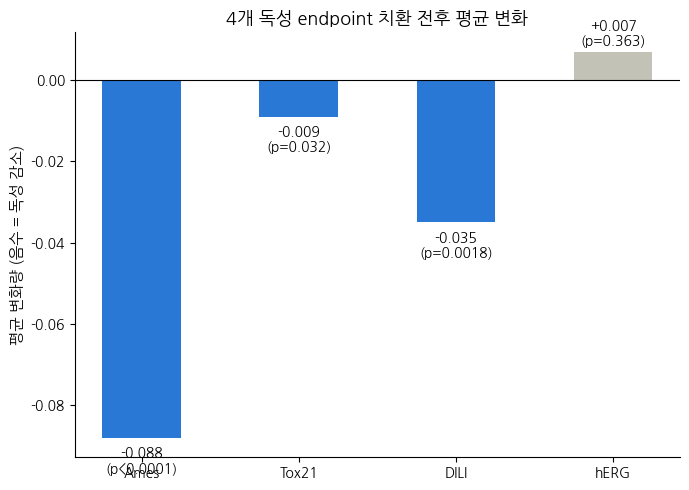

In [ ]:
import matplotlib.pyplot as plt

labels = ['Ames', 'Tox21', 'DILI', 'hERG']
values = [-0.088, -0.009, -0.035, 0.007]
p_values = ['p<0.0001', 'p=0.032', 'p=0.0018', 'p=0.363']
colors = ['#2a78d6', '#2a78d6', '#2a78d6', '#c3c2b7']  # 유의=파랑, 미유의=회색

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5)

for bar, pval, val in zip(bars, p_values, values):
    height = bar.get_height()
    ax.annotate(f'{val:+.3f}\n({pval})',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5 if height >= 0 else -25),
                textcoords="offset points",
                ha='center', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('평균 변화량 (음수 = 독성 감소)', fontsize=11)
ax.set_title('4개 독성 endpoint 치환 전후 평균 변화', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
!cat src/tools/molecule_editor.py


from rdkit import Chem
from rdkit.Chem import rdMMPA
from src.tools.replacement_library import get_replacement_candidates
import hashlib

def _library_version_hash():
    """현재 REPLACEMENT_LIBRARY 내용의 해시값. 라이브러리가 바뀌면
    자동으로 다른 값이 나와서, 캐시 키에 포함시키면 라이브러리 변경 시
    이전 캐시가 자동으로 무효화된다(수동 clear_failure_memory() 호출 불필요)."""
    from src.tools.replacement_library import get_replacement_candidates
    lib = get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY']
    content_str = str(sorted(lib.items()))
    return hashlib.md5(content_str.encode()).hexdigest()[:8]

_FAILURE_MEMORY = {}


def clear_failure_memory():
    """규칙 라이브러리가 업데이트된 뒤(reload 후) 호출해 캐시를 초기화."""
    global _FAILURE_MEMORY
    _FAILURE_MEMORY = {}


def _check_and_match(part_smiles, problem_pattern, pattern_size):
    part_mol = Chem.MolFromSmiles(part_smiles.replace('[*:1]', 'C').replace('[*:2]', 'C'))
    if part_mol is None or not part_mol.HasSubstructMatch(problem_pattern):
        return False
    n_attachment = 

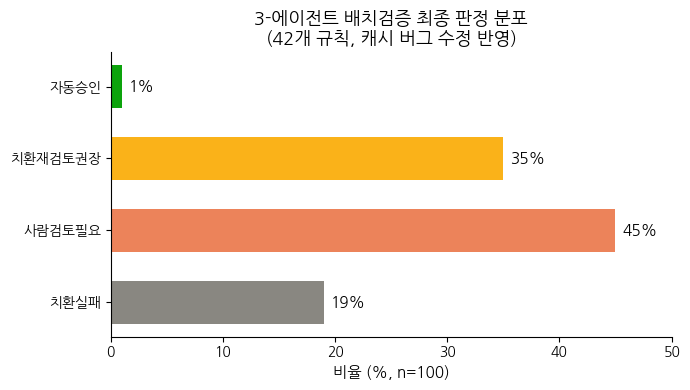

저장: outputs/batch_decision_distribution_final_v2.png


In [ ]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import os
os.makedirs("outputs", exist_ok=True)

categories = ['자동승인', '치환재검토권장', '사람검토필요', '치환실패']
counts = [1, 35, 45, 19]
colors = ['#0ca30c', '#fab219', '#ec835a', '#898781']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(categories, counts, color=colors, height=0.6)
for bar, c in zip(bars, counts):
    width = bar.get_width()
    ax.annotate(f'{c}%', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", va='center', fontsize=11)

ax.set_xlabel('비율 (%, n=100)', fontsize=11)
ax.set_title('3-에이전트 배치검증 최종 판정 분포\n(42개 규칙, 캐시 버그 수정 반영)', fontsize=13)
ax.set_xlim(0, 50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/batch_decision_distribution_final_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print("저장: outputs/batch_decision_distribution_final_v2.png")

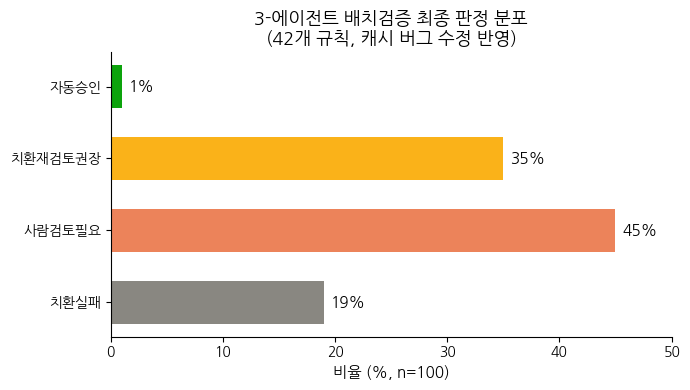

저장: outputs/batch_decision_distribution_final_v2.png


In [ ]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import os
os.makedirs("outputs", exist_ok=True)

categories = ['자동승인', '치환재검토권장', '사람검토필요', '치환실패']
counts = [1, 35, 45, 19]
colors = ['#0ca30c', '#fab219', '#ec835a', '#898781']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(categories, counts, color=colors, height=0.6)
for bar, c in zip(bars, counts):
    width = bar.get_width()
    ax.annotate(f'{c}%', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", va='center', fontsize=11)
ax.set_xlabel('비율 (%, n=100)', fontsize=11)
ax.set_title('3-에이전트 배치검증 최종 판정 분포\n(42개 규칙, 캐시 버그 수정 반영)', fontsize=13)
ax.set_xlim(0, 50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/batch_decision_distribution_final_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print("저장: outputs/batch_decision_distribution_final_v2.png")

In [ ]:
with open("docs/experiment_results_log.md", "a") as f:
    f.write("""
## 2026-08-06 — 3-에이전트 배치검증 최종 확정 (42개 규칙, 캐시버그 수정 후)

캐시 버전관리 버그 수정(_library_version_hash 추가) + Aliphatic_long_chain
안전한 SMARTS 확장 반영 후 100개 표본 재검증(coordinate_agents_v2,
qwen3.8-max).

| 카테고리 | 개수 |
|---|---|
| 치환 실패 | 19 |
| 치환 재검토 권장 | 35 |
| 사람 검토 필요 | 45 |
| 자동 승인 | 1 (hydroquinone, 변함없이 유지) |

이전(41개 규칙, 캐시버그 있던 상태) 대비 치환 실패 26->19건으로 개선.
""")
print("로그 업데이트 완료")

로그 업데이트 완료


In [ ]:
!git add outputs/batch_decision_distribution_final_v2.png docs/experiment_results_log.md
!git commit -m "Final batch validation (42 rules, post cache-versioning fix): 19 failures (down from 26), 35 reconsider, 45 human review, 1 auto-approval."
!git push origin main

[main 0e63342] Final batch validation (42 rules, post cache-versioning fix): 19 failures (down from 26), 35 reconsider, 45 human review, 1 auto-approval.
 2 files changed, 15 insertions(+)
 create mode 100644 outputs/batch_decision_distribution_final_v2.png
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 46.29 KiB | 11.57 MiB/s, done.
Total 6 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/Dec32th/laidd-2026.git
   514a289..0e63342  main -> main


In [ ]:
from google.colab import files

files.download('outputs/batch_decision_distribution_final_v2.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>